# Liu (2025) Cross-Sectional Recreation — v12

Clean rebuild using `liu_exact_replication_v2.csv` (April 2026 pipeline) +
`liu_exact_replication_v2_IFG_addon.csv` (May 2026 IFG add-on).

**v12 change:** Cell 12 (per-category Crawford t) rewritten as mirror-folded Euclidean distance to ctrl centroid in reference hemi (face=R, others=L). Patient peaks reflected across midline if intact_hemi differs from ref. Ctrl null = leave-one-out distance to remaining-ctrl centroid.\n\n**v11 change:** word ROIs (VWFA, STG, pSTG_liu, IFG) now follow Liu's anchoring —
controls' LH distribution as the comparison reference for all patients regardless
of intact hemisphere. Patient values come from the intact hemi (which is the only
side available for L-resection patients). Face/house/object/EVC remain anatomic
homolog (patient intact hemi vs controls' same hemi). Affects Cells 16, 18, 20,
25, 27 (distinctiveness rows only — sum-selectivity unchanged).

**Figures:**
- Fig 2C–H — Per-subject ROI peak scatter (incl. IFG)
- Fig 2I/J  — Spatial topography Crawford *t* (lateralization-sensitive chain;
  IFG NOT in chain — frontal, not ventral)
- Fig 2I/J per-cat — Per-category Crawford *t* (top-level cats only — no IFG)
- Fig 3A/B  — Example RDMs (1×5: ctrl LH | LH-pt mean | ctrl RH | RH-pt mean | TC RH)
- Fig 3D    — Per-ROI Fisher-z boxplots; word ROIs as single pooled panels
- Fig 3E    — Per-ROI Crawford *t*; word panels compare to ctrl LH
- Fig 3E′   — Per-category-pair Crawford *t*; word panels compare to ctrl LH
- Sum-selectivity — Top-level cats only — no IFG pooled into 'word' (frontal vs
  ventral kept separate)

**IFG integration rule:** any cell that shows individual sub-ROIs (face_FFA,
face_STS, etc.) includes word_IFG. Any cell that shows only the four top-level
categories (face/house/object/word) does not.

**Liu overlap:** sub-004 (UD), sub-021 (TC), sub-007 (OT)


## 1. Setup

In [38]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE    = Path(processed_dir)
LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/liu_exact_replication_v2.csv')
FIG_DIR = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact')
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE     = ['sub-017']
EXCLUDE_SES = [('sub-108', 2)]
LIU_CODES   = {'sub-004': 'UD', 'sub-021': 'TC', 'sub-007': 'OT',
               'sub-044': 'SN', 'sub-099': 'KN'}

# Build SUB_CODES from sub_info.csv: code if available, else sub-XXX number
_info_df = pd.read_csv('/user_data/csimmon2/git_repos/sym_pt/sub_info.csv')
SUB_CODES = {row['sub']: (row['code'] if pd.notna(row['code']) and row['code'] != '' else row['sub'].replace('sub-', ''))
             for _, row in _info_df.drop_duplicates('sub').iterrows()}

# FDR: 'bh' = Benjamini-Hochberg (liberal); 'by' = Benjamini-Yekutieli (Liu's choice);
# None = disable correction.
FDR_METHOD = 'bh'

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'LIU_CSV : {LIU_CSV}')
print(f'FIG_DIR : {FIG_DIR}')
print(f'FDR     : {FDR_METHOD}')


LIU_CSV : /user_data/csimmon2/git_repos/sym_pt/liu_exact_replication_v2.csv
FIG_DIR : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact
FDR     : bh


## 2. Load data

Controls → first session; OTC patients → last session.

- `le`: long-format (one row per subject × session × roi × pair)
- `le_summary`: one row per subject × session × roi
- `ctrl_le`/`pt_le`: session-selected summary
- `ctrl_pw`/`pt_pw`: session-selected pairwise (for RDMs)

In [39]:
le = pd.read_csv(LIU_CSV)
addon = LIU_CSV.parent / 'liu_exact_replication_v2_IFG_addon.csv'
if addon.exists():
    le = pd.concat([le, pd.read_csv(addon)], ignore_index=True)
    print(f'Merged IFG addon: +{(pd.read_csv(addon)["subject_id"]).nunique()} subj')
le = le[~le['subject_id'].isin(EXCLUDE)]
le['ses_num'] = pd.to_numeric(le['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    le = le[~((le['subject_id'] == bad_sub) & (le['ses_num'] == bad_ses))]

le_summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates().copy()

# Controls → first session
ctrl_all = le_summary[le_summary['status'] == 'control']
fs = ctrl_all.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
ctrl_le = ctrl_all.merge(fs, on='subject_id')
ctrl_le = ctrl_le[ctrl_le['ses_num'] == ctrl_le['keep']].drop(columns='keep')

# OTC patients → last session
pt_all = le_summary[le_summary['group'] == 'OTC']
ls = pt_all.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
pt_le = pt_all.merge(ls, on='subject_id')
pt_le = pt_le[pt_le['ses_num'] == pt_le['keep']].drop(columns='keep')

# Pairwise: filter le directly, NOT via le_summary
ctrl_pw = le[le['status'] == 'control'].merge(fs, on='subject_id')
ctrl_pw = ctrl_pw[ctrl_pw['ses_num'] == ctrl_pw['keep']].drop(columns='keep')
pt_pw = le[le['group'] == 'OTC'].merge(ls, on='subject_id')
pt_pw = pt_pw[pt_pw['ses_num'] == pt_pw['keep']].drop(columns='keep')

ctrl_subs = sorted(ctrl_le['subject_id'].unique())
otc_subs  = sorted(pt_le['subject_id'].unique())

print(f'Controls: {len(ctrl_subs)}')
print(f'OTC patients: {len(otc_subs)}')
print(f'  Liu overlap: {[s for s in otc_subs if s in LIU_CODES]}')
print(f'ctrl_pw rows: {len(ctrl_pw)}, pt_pw rows: {len(pt_pw)}')

Merged IFG addon: +69 subj
Controls: 38
OTC patients: 22
  Liu overlap: ['sub-004', 'sub-021', 'sub-044', 'sub-099']
ctrl_pw rows: 5548, pt_pw rows: 1606


In [40]:
print(ctrl_pw[ctrl_pw['subject_id']=='sub-018'][['category','hemi','pair']].drop_duplicates())

     category hemi          pair
292  face_FFA    l    face-house
293  face_FFA    l   face-object
294  face_FFA    l     face-word
295  face_FFA    l  house-object
296  face_FFA    l    house-word
..        ...  ...           ...
519  word_IFG    r   face-object
520  word_IFG    r     face-word
521  word_IFG    r  house-object
522  word_IFG    r    house-word
523  word_IFG    r   object-word

[122 rows x 3 columns]


## 3. Helpers

In [41]:
def crawford(x, c):
    """Crawford & Howell (1998) modified t, returns (t, p)."""
    c = np.asarray(c); c = c[~np.isnan(c)]
    if len(c) < 3 or np.isnan(x): return np.nan, np.nan
    m, sd = c.mean(), c.std(ddof=1)
    if sd == 0: return np.nan, np.nan
    t = (x - m) / (sd * np.sqrt((len(c) + 1) / len(c)))
    p = 2 * (1 - tdist.cdf(abs(t), df=len(c) - 1))
    return t, p

def fisher_z(r):
    r = np.clip(np.asarray(r, float), -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))

def fdr_correct(p_values, method='bh', alpha=0.05):
    """FDR correction. 'bh' (Benjamini-Hochberg, liberal) or 'by' (Benjamini-Yekutieli).
    Returns boolean mask of significant tests."""
    p = np.asarray(p_values, float)
    valid = ~np.isnan(p)
    p_valid = p[valid]
    n = len(p_valid)
    if n == 0: return np.zeros_like(p, bool)
    order = np.argsort(p_valid)
    ranked = p_valid[order]
    if method == 'bh':
        thresh = np.arange(1, n + 1) / n * alpha
    elif method == 'by':
        c_n = np.sum(1.0 / np.arange(1, n + 1))
        thresh = np.arange(1, n + 1) / (n * c_n) * alpha
    else:
        raise ValueError(f"method must be 'bh' or 'by', got {method!r}")
    passed = ranked <= thresh
    max_idx = np.where(passed)[0].max() if passed.any() else -1
    sig_valid = np.zeros(n, bool)
    if max_idx >= 0:
        sig_valid[order[:max_idx + 1]] = True
    sig = np.zeros_like(p, bool)
    sig[valid] = sig_valid
    return sig

def pt_intact_hemi(sub):
    sd = pt_le[pt_le['subject_id'] == sub]
    if sd.empty: return None
    intact = sd['intact_hemi'].iloc[0]
    return 'l' if intact == 'left' else 'r' if intact == 'right' else None

WORD_CATS = {'word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'}

## 4. Fig 2C–H — Per-subject ROI peak scatter (native space)

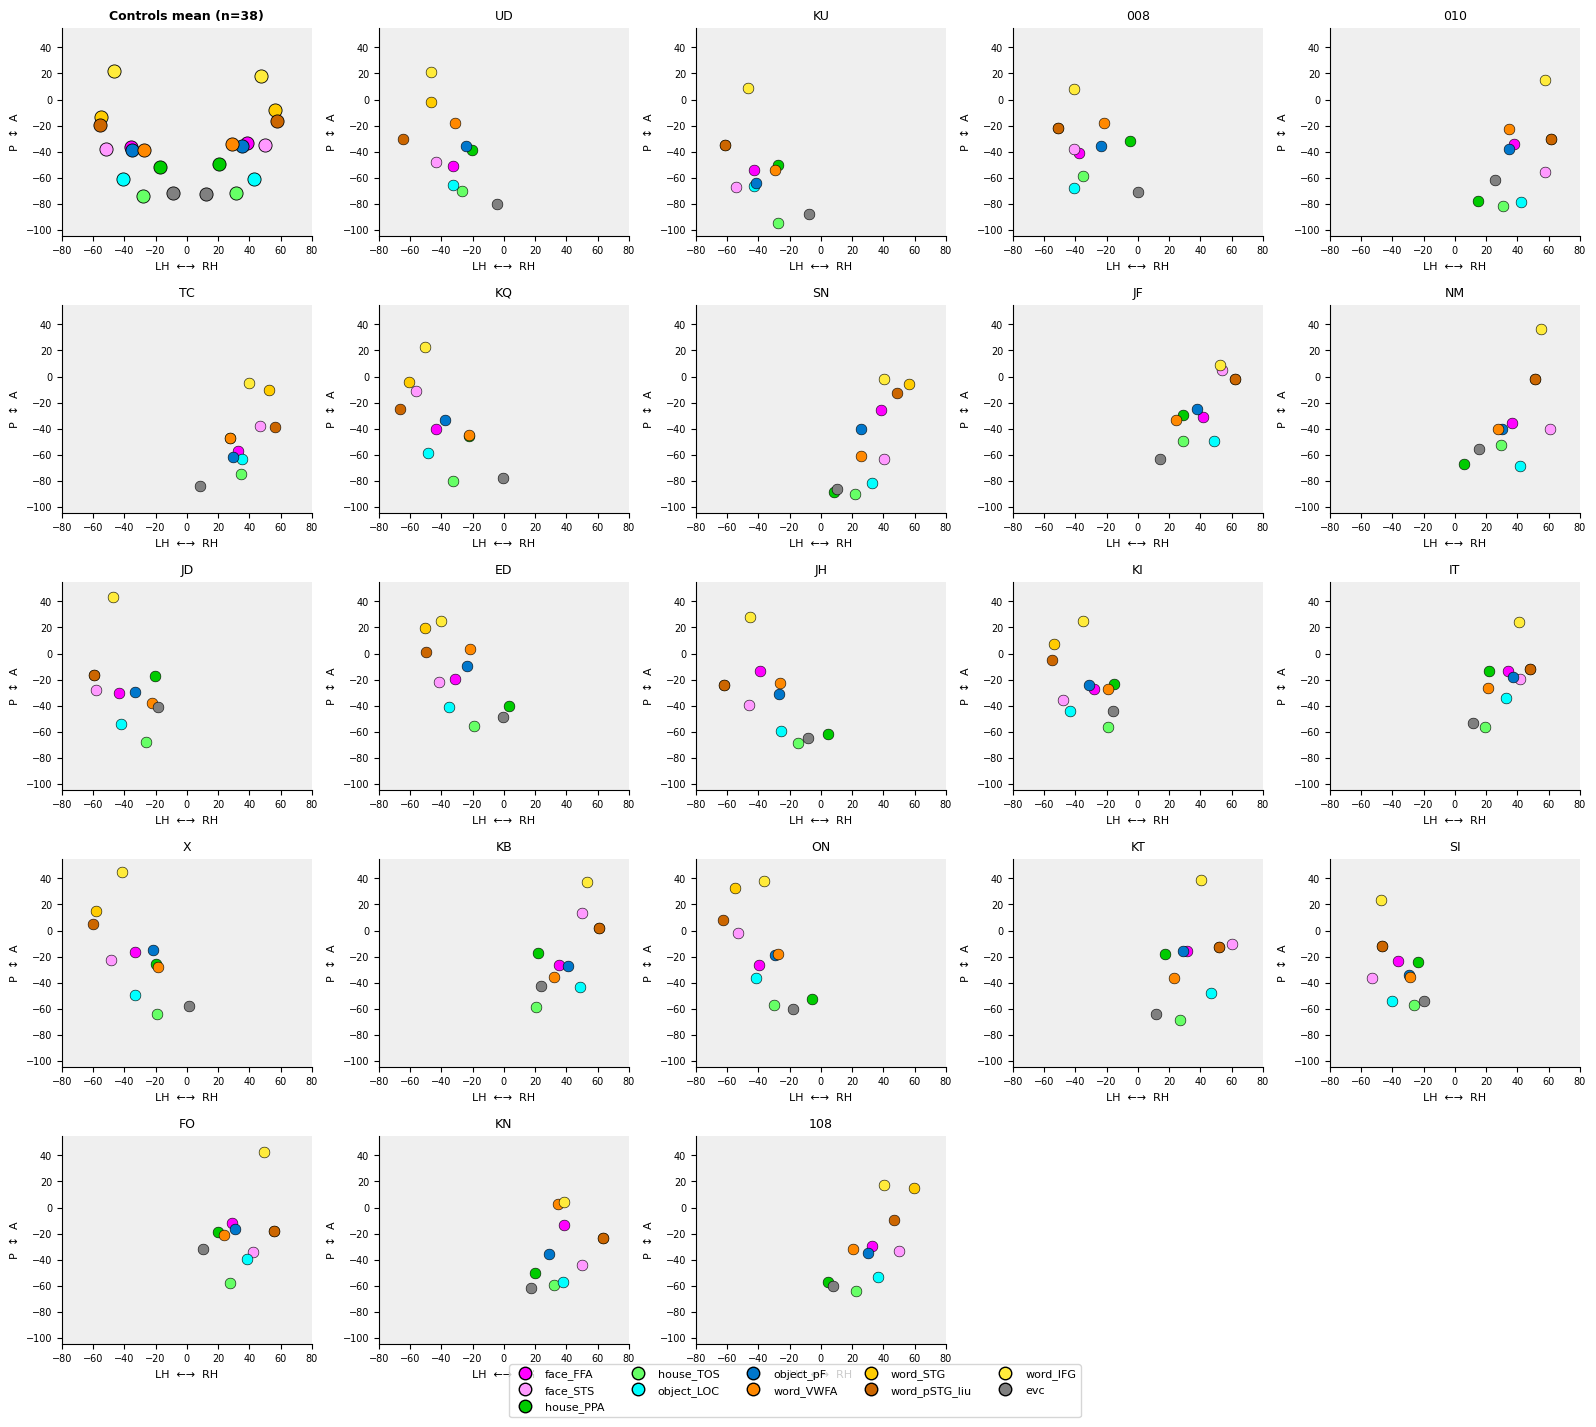

In [42]:
ROI_COLOR = {
    'face_FFA':   'magenta',  'face_STS':    '#ff99ff',
    'house_PPA':  '#00cc00',  'house_TOS':   '#66ff66',
    'object_LOC': 'cyan',     'object_pF':   '#0077cc',
    'word_VWFA':  '#ff8800',  'word_STG':    '#ffcc00',
    'word_pSTG_liu': '#cc6600',
    'word_IFG':   '#ffeb3b',
    'evc':        'gray',
}
ALL_CATS = list(ROI_COLOR.keys())
XLIM = (-80, 80); YLIM = (-105, 55)

def scatter_subject(ax, df, sub, title):
    for cat in ALL_CATS:
        for h in ('l', 'r'):
            m = df[(df['subject_id'] == sub) & (df['category'] == cat) & (df['hemi'] == h)]
            if not len(m): continue
            ax.scatter(m['peak_x_native'].iloc[0], m['peak_y_native'].iloc[0],
                       s=60, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.4)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.set_xlabel('LH  \u2190\u2192  RH', fontsize=8)
    ax.set_ylabel('P  \u2195  A', fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_facecolor('#efefef'); ax.tick_params(labelsize=7)

n_pt  = len(otc_subs)
n_cols = 5
n_rows = int(np.ceil((n_pt + 1) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.8 * n_rows))
axes = axes.flatten()

# Controls mean (per ROI \u00d7 hemi)
ax = axes[0]
for cat in ALL_CATS:
    for h in ('l', 'r'):
        xs, ys = [], []
        for s in ctrl_subs:
            m = ctrl_le[(ctrl_le['subject_id'] == s) & (ctrl_le['category'] == cat) & (ctrl_le['hemi'] == h)]
            if len(m):
                xs.append(m['peak_x_native'].iloc[0]); ys.append(m['peak_y_native'].iloc[0])
        if xs:
            ax.scatter(np.mean(xs), np.mean(ys), s=90, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.6)
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
ax.set_title(f'Controls mean (n={len(ctrl_subs)})', fontsize=9, fontweight='bold')
ax.set_xlabel('LH  \u2190\u2192  RH', fontsize=8); ax.set_ylabel('P  \u2195  A', fontsize=8)
ax.set_facecolor('#efefef'); ax.tick_params(labelsize=7)

for i, s in enumerate(otc_subs):
    label = SUB_CODES.get(s, s.replace('sub-', ''))
    scatter_subject(axes[i + 1], pt_le, s, label)
for j in range(n_pt + 1, len(axes)):
    axes[j].axis('off')

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor='k', markersize=9, label=cat)
                  for cat, c in ROI_COLOR.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig2CH.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Fig 2I/J — Spatial topography Crawford *t*

Liu's ventral key: EVC → PPA → pF → FFA → VWFA (medial → lateral).
Correlate each subject's ventral x-coord vector with the control mean;
Crawford *t* tests patient vs control leave-one-out null.

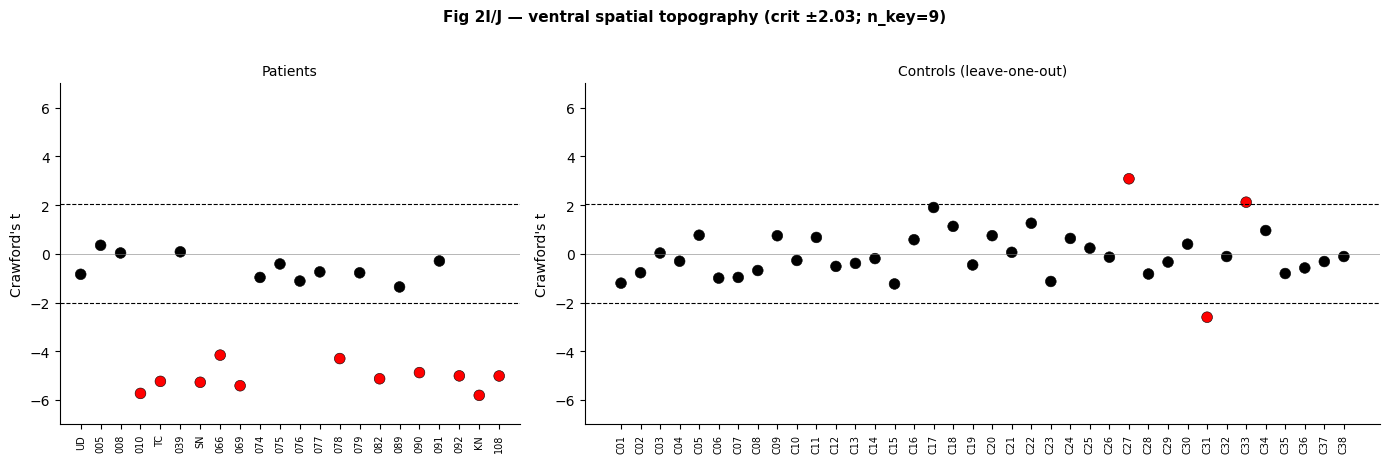

Patient t-values:    {'UD': -0.84, '005': 0.35, '008': 0.03, '010': -5.73, 'TC': -5.24, '039': 0.08, 'SN': -5.28, '066': -4.16, '069': -5.42, '074': -0.97, '075': -0.42, '076': -1.12, '077': -0.74, '078': -4.3, '079': -0.78, '082': -5.13, '089': -1.36, '090': -4.88, '091': -0.3, '092': -5.01, 'KN': -5.81, '108': -5.02}
Control t-range:     [-2.60, 3.08]


In [43]:
VENTRAL_KEY = [('evc',       'l'), ('evc',       'r'),
               ('house_PPA', 'l'), ('house_PPA', 'r'),
               ('object_pF', 'l'), ('object_pF', 'r'),
               ('face_FFA',  'l'), ('face_FFA',  'r'),
               ('word_VWFA', 'PREF')]

def resolve_hemi(hspec, is_ctrl, intact):
    if hspec in ('l', 'r'): return hspec
    if hspec == 'PREF':
        if is_ctrl: return 'l'
        return 'l' if intact == 'left' else 'r' if intact == 'right' else None
    return None

def build_xmat(df, subs, is_ctrl, intact_map):
    X = np.full((len(VENTRAL_KEY), len(subs)), np.nan)
    for i, (cat, hspec) in enumerate(VENTRAL_KEY):
        for j, s in enumerate(subs):
            h = resolve_hemi(hspec, is_ctrl, intact_map.get(s))
            if h is None: continue
            m = df[(df['subject_id'] == s) & (df['category'] == cat) & (df['hemi'] == h)]
            if len(m): X[i, j] = m['peak_x_native'].iloc[0]
    return X

intact_map = dict(zip(le_summary['subject_id'], le_summary['intact_hemi']))
X_ctrl = build_xmat(ctrl_le, ctrl_subs, True, intact_map)
X_pt   = build_xmat(pt_le,   otc_subs,  False, intact_map)
n_ctrl = len(ctrl_subs)

spcor_pt   = np.full(len(otc_subs), np.nan)
null_forpt = np.full((n_ctrl, len(otc_subs)), np.nan)
for p, s in enumerate(otc_subs):
    valid = ~np.isnan(X_pt[:, p])
    if valid.sum() < 3: continue
    pat_vec   = X_pt[valid, p]
    ctrl_sub  = X_ctrl[valid, :]
    mean_ctrl = np.nanmean(ctrl_sub, axis=1)
    ok = ~np.isnan(pat_vec) & ~np.isnan(mean_ctrl)
    if ok.sum() >= 3:
        spcor_pt[p] = np.corrcoef(pat_vec[ok], mean_ctrl[ok])[0, 1]
    for t_idx in range(n_ctrl):
        others = [c for c in range(n_ctrl) if c != t_idx]
        rest   = np.nanmean(ctrl_sub[:, others], axis=1)
        me     = ctrl_sub[:, t_idx]
        ok = ~np.isnan(me) & ~np.isnan(rest)
        if ok.sum() >= 3:
            null_forpt[t_idx, p] = np.corrcoef(me[ok], rest[ok])[0, 1]

spcor_ctrl = np.full(n_ctrl, np.nan)
for c in range(n_ctrl):
    others = [j for j in range(n_ctrl) if j != c]
    rest   = np.nanmean(X_ctrl[:, others], axis=1)
    me     = X_ctrl[:, c]
    ok = ~np.isnan(me) & ~np.isnan(rest)
    if ok.sum() >= 6:
        spcor_ctrl[c] = np.corrcoef(me[ok], rest[ok])[0, 1]

spcor_pt_fz   = fisher_z(spcor_pt)
null_pt_fz    = fisher_z(null_forpt)
spcor_ctrl_fz = fisher_z(spcor_ctrl)

t_pt   = np.array([crawford(spcor_pt_fz[p], null_pt_fz[:, p])[0] for p in range(len(otc_subs))])
t_ctrl = np.array([crawford(spcor_ctrl_fz[c], np.delete(spcor_ctrl_fz, c))[0] for c in range(n_ctrl)])

min_df = max(n_ctrl - 1, 3)
crit_2IJ = float(tdist.ppf(0.975, df=min_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                         gridspec_kw={'width_ratios': [len(otc_subs), n_ctrl]})
pt_labels   = [LIU_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
ctrl_labels = [f'C{i+1:02d}' for i in range(n_ctrl)]

ymax = max(7, int(np.ceil(max(np.nanmax(np.abs(t_pt)), np.nanmax(np.abs(t_ctrl))))) + 1)

for ax, xs, ts, labels, title in [
    (axes[0], np.arange(len(otc_subs)), t_pt, pt_labels, 'Patients'),
    (axes[1], np.arange(n_ctrl), t_ctrl, ctrl_labels, 'Controls (leave-one-out)'),
]:
    colors = ['red' if (not np.isnan(v) and abs(v) > crit_2IJ) else 'black' for v in ts]
    ax.scatter(xs, ts, s=60, c=colors, edgecolors='k', linewidth=0.4)
    ax.axhline( crit_2IJ, color='k', lw=0.8, ls='--')
    ax.axhline(-crit_2IJ, color='k', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-ymax, ymax)
    ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Crawford's t")

plt.suptitle(f'Fig 2I/J — ventral spatial topography (crit ±{crit_2IJ:.2f}; n_key={len(VENTRAL_KEY)})',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig2IJ.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Patient t-values:    {dict(zip(pt_labels, t_pt.round(2)))}')
print(f'Control t-range:     [{np.nanmin(t_ctrl):.2f}, {np.nanmax(t_ctrl):.2f}]')

In [93]:
# ── Cell 11 mirror-flip: rVWFA flipped to LH for L-resection patients ──────
# Replicates Liu Supplementary Table S1. Native coords: midline=0, LH<0, RH>0.
# Mirror flip = negation.

VENTRAL_KEY_LIU = [
    ('face_FFA',  'l'),  ('face_FFA',  'r'),
    ('house_PPA', 'l'),  ('house_PPA', 'r'),
    ('object_pF', 'l'),  ('object_pF', 'r'),
    ('word_VWFA', 'PREF'),
    ('evc',       'l'),  ('evc',       'r'),
]

def resolve_hemi_liu(hspec, is_ctrl, intact):
    """VWFA: ctrl=LH, patient=intact hemi."""
    if hspec in ('l','r'): return hspec
    if hspec == 'PREF':
        if is_ctrl: return 'l'
        return 'l' if intact == 'left' else 'r' if intact == 'right' else None
    return None

def build_xmat_flip(df, subs, is_ctrl, intact_map, flip_cats=('word_VWFA',)):
    """Build x-coord matrix with rVWFA mirror-flipped to LH for RH-intact patients."""
    X = np.full((len(VENTRAL_KEY_LIU), len(subs)), np.nan)
    for i, (cat, hspec) in enumerate(VENTRAL_KEY_LIU):
        for j, s in enumerate(subs):
            h = resolve_hemi_liu(hspec, is_ctrl, intact_map.get(s))
            if h is None: continue
            m = df[(df['subject_id']==s) & (df['category']==cat) & (df['hemi']==h)]
            if not len(m): continue
            x = m['peak_x_native'].iloc[0]
            # Mirror-flip patient's rVWFA: native coords midline=0, so negate
            if (not is_ctrl) and (cat in flip_cats) and (intact_map.get(s) == 'right'):
                x = -x
            X[i, j] = x
    return X

X_ctrl_f = build_xmat_flip(ctrl_le, ctrl_subs, True,  intact_map)
X_pt_f   = build_xmat_flip(pt_le,   otc_subs,  False, intact_map)
n_ctrl = len(ctrl_subs)

# Per-patient correlation: only ROIs the patient has (Liu's `select` mask)
spcor_pt_f   = np.full(len(otc_subs), np.nan)
null_forpt_f = np.full((n_ctrl, len(otc_subs)), np.nan)
for p in range(len(otc_subs)):
    select = ~np.isnan(X_pt_f[:, p])
    if select.sum() < 3: continue
    pat_vec  = X_pt_f[select, p]
    ctrl_sub = X_ctrl_f[select, :]
    mean_ctrl = np.nanmean(ctrl_sub, axis=1)
    ok = ~np.isnan(pat_vec) & ~np.isnan(mean_ctrl)
    if ok.sum() >= 3:
        spcor_pt_f[p] = np.corrcoef(pat_vec[ok], mean_ctrl[ok])[0, 1]
    for t_idx in range(n_ctrl):
        others = [c for c in range(n_ctrl) if c != t_idx]
        rest = np.nanmean(ctrl_sub[:, others], axis=1)
        me   = ctrl_sub[:, t_idx]
        ok = ~np.isnan(me) & ~np.isnan(rest)
        if ok.sum() >= 3:
            null_forpt_f[t_idx, p] = np.corrcoef(me[ok], rest[ok])[0, 1]

spcor_pt_fz_f = fisher_z(spcor_pt_f)
null_pt_fz_f  = fisher_z(null_forpt_f)
t_pt_f = np.array([crawford(spcor_pt_fz_f[p], null_pt_fz_f[:, p])[0]
                   for p in range(len(otc_subs))])
crit = float(tdist.ppf(0.975, df=max(n_ctrl - 1, 3)))

print(f'Crit ±{crit:.2f}\n')
print('Patient t-values with rVWFA mirror-flipped to LH (native coords, x → -x):')
for s, t in zip(otc_subs, t_pt_f):
    code = LIU_CODES.get(s, s.replace('sub-',''))
    intact = pt_intact_hemi(s)
    flag = '*' if not np.isnan(t) and abs(t) > crit else ''
    print(f'  {code:5s} intact={intact}  t={t:+.2f} {flag}')

n_lh = sum(1 for s,t in zip(otc_subs,t_pt_f)
           if pt_intact_hemi(s)=='l' and not np.isnan(t) and abs(t)>crit)
n_rh = sum(1 for s,t in zip(otc_subs,t_pt_f)
           if pt_intact_hemi(s)=='r' and not np.isnan(t) and abs(t)>crit)
print(f'\nLH-intact (R-res): {n_lh}/11 atypical')
print(f'RH-intact (L-res): {n_rh}/11 atypical')

Crit ±2.03

Patient t-values with rVWFA mirror-flipped to LH (native coords, x → -x):
  UD    intact=l  t=-0.84 
  005   intact=l  t=+0.35 
  008   intact=l  t=+0.03 
  010   intact=r  t=-1.32 
  TC    intact=r  t=-0.59 
  039   intact=l  t=+0.08 
  SN    intact=r  t=-0.89 
  066   intact=r  t=+1.18 
  069   intact=r  t=-1.21 
  074   intact=l  t=-0.97 
  075   intact=l  t=-0.42 
  076   intact=l  t=-1.12 
  077   intact=l  t=-0.74 
  078   intact=r  t=+0.85 
  079   intact=l  t=-0.78 
  082   intact=r  t=-0.86 
  089   intact=l  t=-1.36 
  090   intact=r  t=+3.46 *
  091   intact=l  t=-0.30 
  092   intact=r  t=+0.96 
  KN    intact=r  t=-0.17 
  108   intact=r  t=-1.33 

LH-intact (R-res): 0/11 atypical
RH-intact (L-res): 1/11 atypical


In [94]:
ct_l = ctrl_le[(ctrl_le['category']=='word_VWFA')&(ctrl_le['hemi']=='l')].set_index('subject_id')['peak_z']
ct_r = ctrl_le[(ctrl_le['category']=='word_VWFA')&(ctrl_le['hemi']=='r')].set_index('subject_id')['peak_z']
common = ct_l.index.intersection(ct_r.index)
n_rh_stronger = (ct_r.loc[common] > ct_l.loc[common]).sum()
print(f'{n_rh_stronger}/{len(common)} controls have stronger RH VWFA than LH')

14/38 controls have stronger RH VWFA than LH


In [104]:
# ── Verify distance measure anchors are hemi-matched (no Liu anchoring issue) ──
mni_df = pd.read_csv('/user_data/csimmon2/sym_pt/group_results/peak_coords/peak_coords_mni.csv')

print('Distance measure anchor check:\n')
print(f'{"ROI":18s} {"intact":7s} {"ctrl_n":7s} {"ctrl_centroid_x":17s} {"pt_n":5s} {"pt_mean_x":10s}')
print('-' * 75)

for roi in ALL_ROIS_FLAT:
    for intact, label in [('l','LH-intact'), ('r','RH-intact')]:
        # Controls: same hemi as patient's intact side
        c = mni_df[mni_df['subject_id'].isin(ctrl_subs) &
                   (mni_df['category']==roi) &
                   (mni_df['hemi']==intact)][['peak_x_mni','peak_y_mni']].dropna().values
        c = mni_df[mni_df['subject_id'].isin(ctrl_subs) & (mni_df['category']==roi) & (mni_df['hemi']==intact)] \
            .drop_duplicates(subset=['subject_id'])[['peak_x_mni','peak_y_mni']].dropna().values
        # Patients: their intact hemi
        pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        p = mni_df[mni_df['subject_id'].isin(pt_subs) &
                   (mni_df['category']==roi) &
                   (mni_df['hemi']==intact)][['peak_x_mni','peak_y_mni']].dropna().values
        if len(c) < 3 or len(p) < 2: continue
        cen = c.mean(0)
        print(f'{roi:18s} {intact:7s} {len(c):<7d} {cen[0]:+17.2f} {len(p):<5d} {p[:,0].mean():+10.2f}')

print('\nDistance compares pt and ctrl in the SAME hemisphere per ROI.')
print('Sign of x should match between ctrl_centroid and pt_mean for every row.')
print('No Liu-style cross-hemisphere anchoring.')

Distance measure anchor check:

ROI                intact  ctrl_n  ctrl_centroid_x   pt_n  pt_mean_x 
---------------------------------------------------------------------------
face_FFA           l       38                 -39.39 102       -40.76
face_FFA           r       38                 +40.17 78        +39.08
face_STS           l       38                 -55.84 102       -55.08
face_STS           r       38                 +52.64 78        +54.85
house_PPA          l       38                 -19.34 102       -16.62
house_PPA          r       38                 +21.24 78        +16.64
house_TOS          l       38                 -31.16 102       -29.10
house_TOS          r       38                 +32.39 78        +31.47
object_LOC         l       38                 -44.94 102       -41.98
object_LOC         r       38                 +44.90 78        +43.17
object_pF          l       38                 -38.32 102       -34.23
object_pF          r       38                 +36.43

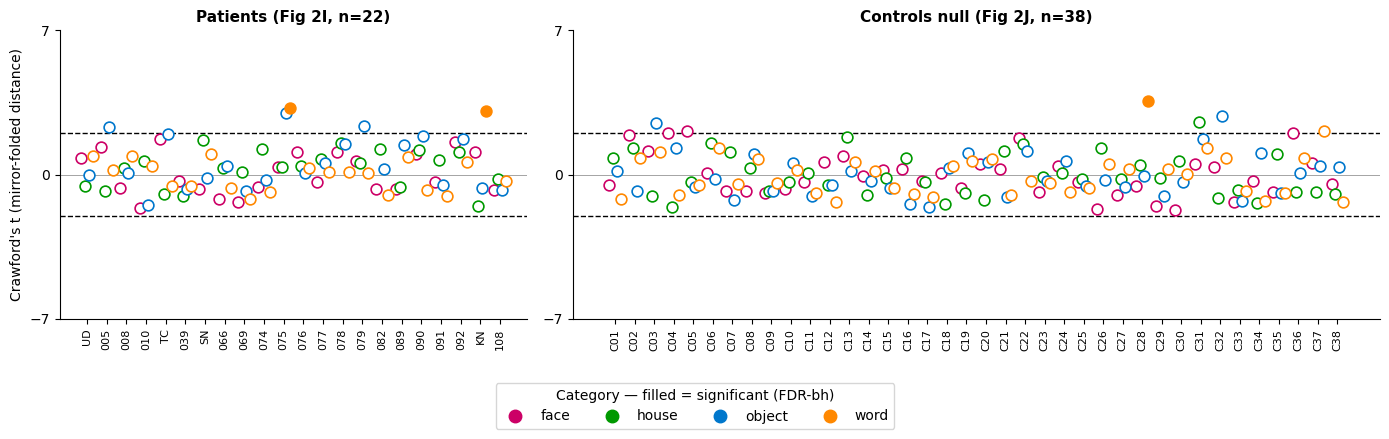

In [96]:
# Per-category distance Crawford t (mirror-folded).
# Patient peak is mirror-folded to category's reference hemi if intact_hemi differs.
# Distance = Euclidean (x,y) from peak to ctrl centroid in ref hemi.
# Ctrl null = leave-one-out distance (each ctrl to centroid of remaining ctrls).

CAT_ROI = [
    ('face',   'face_FFA'),
    ('house',  'house_PPA'),
    ('object', 'object_pF'),
    ('word',   'word_VWFA'),
]
CAT_COLOR_2IJ = {'face': '#cc0066', 'house': '#009900',
                 'object': '#0077cc', 'word': '#ff8800'}
REF_HEMI = {'face': 'r', 'house': 'l', 'object': 'l', 'word': 'l'}

def get_xy(df, sub, cat, h):
    m = df[(df['subject_id'] == sub) & (df['category'] == cat) & (df['hemi'] == h)]
    if len(m) == 0: return np.nan, np.nan
    return m['peak_x_native'].iloc[0], m['peak_y_native'].iloc[0]

def midline_for(roi):
    lx = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']=='l')]['peak_x_native'].mean()
    rx = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']=='r')]['peak_x_native'].mean()
    return (lx + rx) / 2

t_cat_pt   = {cat: np.full(len(otc_subs), np.nan) for cat, _ in CAT_ROI}
p_cat_pt   = {cat: np.full(len(otc_subs), np.nan) for cat, _ in CAT_ROI}
t_cat_ctrl = {cat: np.full(n_ctrl, np.nan) for cat, _ in CAT_ROI}
p_cat_ctrl = {cat: np.full(n_ctrl, np.nan) for cat, _ in CAT_ROI}

for cat, roi in CAT_ROI:
    ref = REF_HEMI[cat]
    mid = midline_for(roi)

    # Ctrl coords in ref hemi
    ctrl_pts, ctrl_idx = [], []
    for c, s in enumerate(ctrl_subs):
        x, y = get_xy(ctrl_le, s, roi, ref)
        if not np.isnan(x):
            ctrl_pts.append([x, y]); ctrl_idx.append(c)
    if len(ctrl_pts) < 3: continue
    ctrl_pts = np.array(ctrl_pts)
    ctrl_centroid = ctrl_pts.mean(0)

    # Ctrl LOO distances
    ctrl_d = np.array([np.linalg.norm(ctrl_pts[i] - np.delete(ctrl_pts, i, 0).mean(0))
                       for i in range(len(ctrl_pts))])

    # Ctrl Crawford t (each ctrl vs others\u2019 distance dist)
    for i, c in enumerate(ctrl_idx):
        others = np.delete(ctrl_d, i)
        if len(others) >= 3:
            t_cat_ctrl[cat][c], p_cat_ctrl[cat][c] = crawford(ctrl_d[i], others)

    # Patient distances (mirror-fold if intact != ref)
    for p, sub in enumerate(otc_subs):
        pt_h = pt_intact_hemi(sub)
        if pt_h is None: continue
        x, y = get_xy(pt_le, sub, roi, pt_h)
        if np.isnan(x): continue
        if pt_h != ref:
            x = 2 * mid - x  # reflect across midline
        d = np.linalg.norm(np.array([x, y]) - ctrl_centroid)
        t_cat_pt[cat][p], p_cat_pt[cat][p] = crawford(d, ctrl_d)

min_df_2IJ = max(n_ctrl - 1, 3)
crit_2IJ = float(tdist.ppf(0.975, df=min_df_2IJ))

sig_cat_pt   = {cat: np.abs(t_cat_pt[cat])   > crit_2IJ for cat, _ in CAT_ROI}
sig_cat_ctrl = {cat: np.abs(t_cat_ctrl[cat]) > crit_2IJ for cat, _ in CAT_ROI}
if FDR_METHOD is not None:
    for cat, _ in CAT_ROI:
        sig_cat_pt[cat]   = fdr_correct(p_cat_pt[cat],   method=FDR_METHOD)
        sig_cat_ctrl[cat] = fdr_correct(p_cat_ctrl[cat], method=FDR_METHOD)

all_vals = np.concatenate([
    np.concatenate([values[cat] for cat, _ in CAT_ROI])
    for values in [t_cat_pt, t_cat_ctrl]
])
ymax = max(7, int(np.ceil(np.nanmax(np.abs(all_vals)))) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                         gridspec_kw={'width_ratios': [len(otc_subs), n_ctrl]})
pt_labels   = [LIU_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
ctrl_labels = [f'C{i+1:02d}' for i in range(n_ctrl)]
offsets = {'face': -0.3, 'house': -0.1, 'object': 0.1, 'word': 0.3}

for ax, values, sig_map, labels, title, n_xs in [
    (axes[0], t_cat_pt,   sig_cat_pt,   pt_labels,   f'Patients (Fig 2I, n={len(otc_subs)})', len(otc_subs)),
    (axes[1], t_cat_ctrl, sig_cat_ctrl, ctrl_labels, f'Controls null (Fig 2J, n={n_ctrl})',    n_ctrl),
]:
    for cat, _ in CAT_ROI:
        xs = np.arange(n_xs) + offsets[cat]
        tv = values[cat]
        for i in range(n_xs):
            if np.isnan(tv[i]): continue
            is_sig = sig_map[cat][i]
            ax.scatter(xs[i], tv[i], s=60,
                       facecolors=CAT_COLOR_2IJ[cat] if is_sig else 'white',
                       edgecolors=CAT_COLOR_2IJ[cat], linewidth=1.2, zorder=3)
    ax.axhline( crit_2IJ, color='k', lw=1.0, ls='--')
    ax.axhline(-crit_2IJ, color='k', lw=1.0, ls='--')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_ylim(-ymax, ymax); ax.set_yticks([-ymax, 0, ymax])
    ax.set_xticks(np.arange(n_xs))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
axes[0].set_ylabel("Crawford's t (mirror-folded distance)")

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor=c, markersize=9, label=cat)
                  for cat, c in CAT_COLOR_2IJ.items()]
suffix = f' (FDR-{FDR_METHOD})' if FDR_METHOD else ''
plt.tight_layout()
fig.subplots_adjust(bottom=0.28)
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 0.02),
           title=f'Category \u2014 filled = significant{suffix}')
plt.savefig(FIG_DIR / 'liu_exact_fig2IJ_overlay.png', dpi=300, bbox_inches='tight')
plt.show()


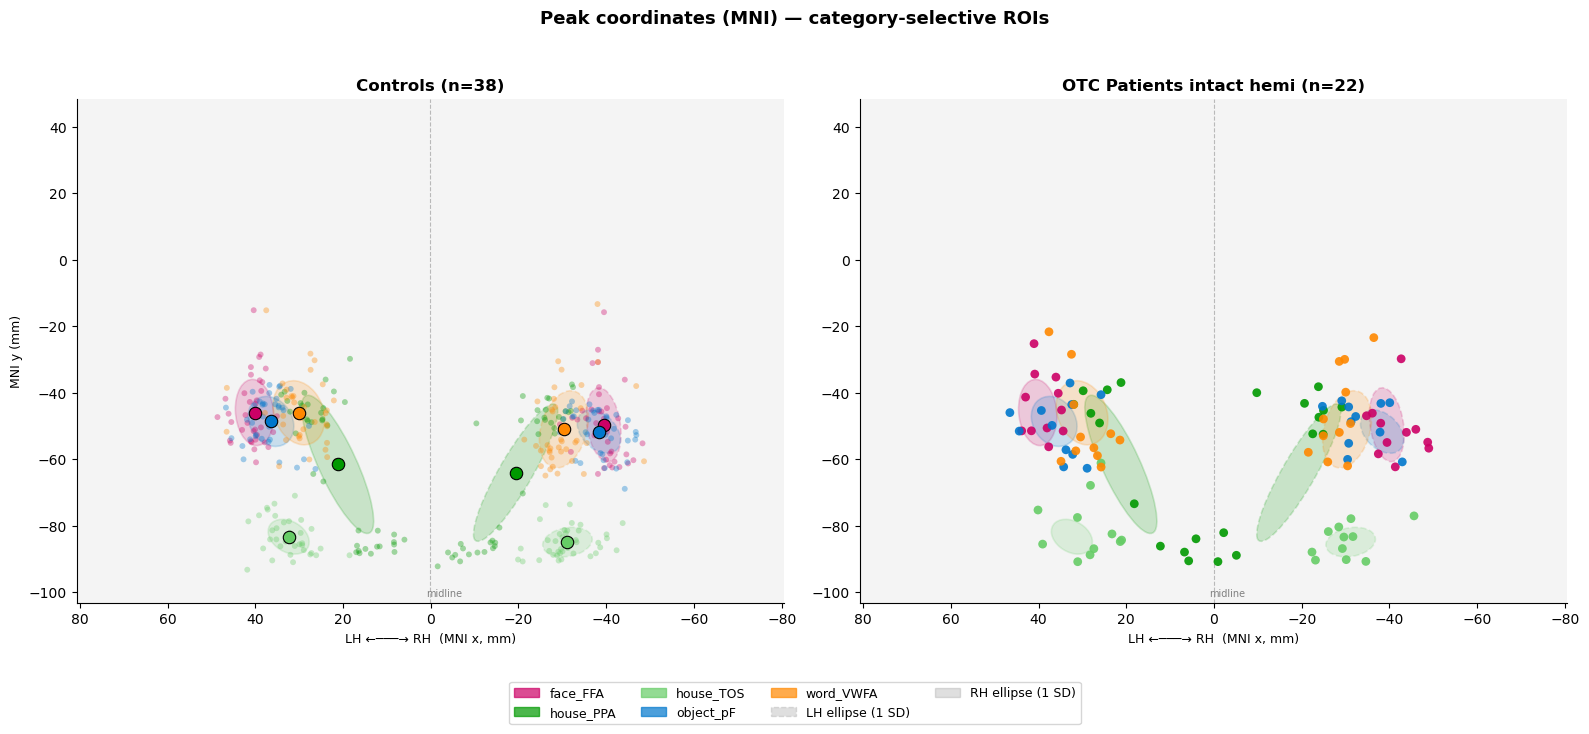

In [45]:
# Peak coordinate scatter (MNI) — Controls (ellipses) | Patients (dots)
# Reads peak_coords_mni.csv produced by calc_peak_coords_mni.py.

from pathlib import Path
from matplotlib.patches import Patch, Ellipse
import matplotlib.transforms as mtransforms

MNI_CSV = Path(processed_dir) / 'group_results' / 'peak_coords' / 'peak_coords_mni.csv'

CATS_PEAK = [
    ('face_FFA',  '#cc0066'),
    ('house_PPA', '#009900'),
    ('house_TOS', '#66cc66'),
    ('object_pF', '#0077cc'),
    ('word_VWFA', '#ff8800'),
]


def confidence_ellipse(x, y, ax, n_std=1.0, **kw):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson); ry = np.sqrt(1 - pearson)
    e = Ellipse((0, 0), width=2 * rx, height=2 * ry, **kw)
    sx = np.sqrt(cov[0, 0]) * n_std; sy = np.sqrt(cov[1, 1]) * n_std
    t = (mtransforms.Affine2D().rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    e.set_transform(t + ax.transData); ax.add_patch(e)


# ── Load + session filter (matches Cell 4) ────────────────────────────────────
mni = pd.read_csv(MNI_CSV)
mni = mni[~mni['subject_id'].isin(EXCLUDE)]
mni['ses_num'] = pd.to_numeric(mni['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    mni = mni[~((mni['subject_id'] == bad_sub) & (mni['ses_num'] == bad_ses))]

ctrl = mni[mni['status'] == 'control'].copy()
fs   = ctrl.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'k'})
ctrl = ctrl.merge(fs, on='subject_id')
ctrl = ctrl[ctrl['ses_num'] == ctrl['k']].drop(columns='k')

pt   = mni[mni['group'] == 'OTC'].copy()
ls   = pt.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'k'})
pt   = pt.merge(ls, on='subject_id')
pt   = pt[pt['ses_num'] == pt['k']].drop(columns='k')

ctrl_subs_mni = sorted(ctrl['subject_id'].unique())
pt_subs_mni   = sorted(pt['subject_id'].unique())


def coords(df, sub, roi, h):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == h)]
    if len(m) == 0: return None
    x, y = float(m['peak_x_mni'].iloc[0]), float(m['peak_y_mni'].iloc[0])
    return None if (np.isnan(x) or np.isnan(y)) else (x, y)


def intact(sub):
    m = pt[pt['subject_id'] == sub]
    return None if m.empty else ('l' if m['intact_hemi'].iloc[0] == 'left' else 'r')


# Limits + midline
all_xy = ctrl[['peak_x_mni', 'peak_y_mni']].dropna().values
xlim = (all_xy[:, 0].min() - 10, all_xy[:, 0].max() + 10)
ylim = (all_xy[:, 1].min() - 10, all_xy[:, 1].max() + 10)
lx = ctrl[ctrl['hemi'] == 'l']['peak_x_mni'].mean()
rx = ctrl[ctrl['hemi'] == 'r']['peak_x_mni'].mean()
midline = (lx + rx) / 2

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

for ax_idx, (ax, is_ctrl) in enumerate([(axes[0], True), (axes[1], False)]):
    ax.set_facecolor('#f4f4f4')
    for roi, color in CATS_PEAK:
        for hemi, ls in [('l', '--'), ('r', '-')]:
            pts = [coords(ctrl, s, roi, hemi) for s in ctrl_subs_mni]
            pts = np.array([p for p in pts if p is not None])
            if len(pts) < 3: continue
            x, y = pts[:, 0], pts[:, 1]
            confidence_ellipse(x, y, ax, n_std=1.0,
                               facecolor=color, alpha=0.18,
                               edgecolor=color, linewidth=1.2,
                               linestyle=ls)
            if is_ctrl:
                ax.scatter(x, y, color=color, alpha=0.35, s=18, edgecolors='none', zorder=3)
                ax.scatter(x.mean(), y.mean(), color=color, s=80,
                           edgecolors='black', linewidth=0.8, marker='o', zorder=5)
        if not is_ctrl:
            for sub in pt_subs_mni:
                pt_h = intact(sub)
                if pt_h is None: continue
                p = coords(pt, sub, roi, pt_h)
                if p is None: continue
                ax.scatter(p[0], p[1], color=color, s=40,
                           edgecolors='none', alpha=0.9, zorder=6)

    ax.axvline(midline, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)
    ax.text(midline + 1, ylim[0] + 2, 'midline', fontsize=7, color='gray')
    ax.set_xlim(xlim); ax.invert_xaxis(); ax.set_ylim(ylim)
    ax.set_xlabel('LH \u2190\u2500\u2500\u2500\u2192 RH  (MNI x, mm)', fontsize=9)
    if ax_idx == 0:
        ax.set_ylabel('MNI y (mm)', fontsize=9)
        ax.set_title(f'Controls (n={len(ctrl_subs_mni)})', fontsize=12, fontweight='bold')
    else:
        ax.set_title(f'OTC Patients intact hemi (n={len(pt_subs_mni)})',
                     fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

leg = [Patch(facecolor=c, alpha=0.7, edgecolor=c, label=cat) for cat, c in CATS_PEAK]
leg += [
    Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='--', label='LH ellipse (1 SD)'),
    Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='-',  label='RH ellipse (1 SD)'),
]
fig.legend(handles=leg, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Peak coordinates (MNI) — category-selective ROIs', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(FIG_DIR / 'peak_scatter_mni.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
# Per-category Euclidean distance: which cat moves most in L-res vs R-res patients?
# Patient distance = ‖peak_pt - ctrl_centroid‖ in 2D (MNI x, y), at intact hemi.
# Ctrl null = leave-one-out distance to remaining ctrl centroid.
# Crawford t per patient × cat. Summarized by surgery side.

CATS = ['face_FFA', 'house_PPA', 'house_TOS', 'object_pF', 'word_VWFA']

def _xy(df, sub, roi, h):
    m = df[(df['subject_id']==sub) & (df['category']==roi) & (df['hemi']==h)]
    if len(m)==0: return None
    x, y = float(m['peak_x_mni'].iloc[0]), float(m['peak_y_mni'].iloc[0])
    return None if np.isnan(x) or np.isnan(y) else np.array([x, y])

rows = []
for cat in CATS:
    for hemi in ('l', 'r'):
        # Ctrl points in this hemi
        cpts = [_xy(ctrl, s, cat, hemi) for s in ctrl_subs_mni]
        cpts = np.array([p for p in cpts if p is not None])
        if len(cpts) < 4: continue

        # Ctrl LOO distances
        cd = np.array([np.linalg.norm(cpts[i] - np.delete(cpts, i, 0).mean(0))
                       for i in range(len(cpts))])
        ctrl_centroid = cpts.mean(0)

        # Patient distances (only patients with intact hemi == hemi)
        for sub in pt_subs_mni:
            pt_h = intact(sub)
            if pt_h != hemi: continue
            p = _xy(pt, sub, cat, hemi)
            if p is None: continue
            d = np.linalg.norm(p - ctrl_centroid)
            t, pval = crawford(d, cd)
            surg = 'L-res' if pt_h == 'r' else 'R-res'
            rows.append({'sub': sub, 'category': cat, 'intact': hemi,
                         'surg_side': surg, 'distance': d, 'ctrl_mean': cd.mean(),
                         't': t, 'p': pval})

ddf = pd.DataFrame(rows)

# Summary: mean distance + mean t per cat × surg side
print('Per-category mean distance (mm) and mean Crawford t, by surgery side:')
print('=' * 75)
summary = (ddf.groupby(['surg_side', 'category'])
              .agg(n=('sub','count'), dist_mean=('distance','mean'),
                   dist_sd=('distance','std'), ctrl_mean=('ctrl_mean','mean'),
                   t_mean=('t','mean'), t_max=('t','max'))
              .round(2))
print(summary.to_string())

# Rank: which cat has largest mean distance per surg side
print('\nRank by mean distance (largest = most displaced):')
for side in ['L-res', 'R-res']:
    sub = (ddf[ddf['surg_side']==side]
           .groupby('category')['distance'].mean()
           .sort_values(ascending=False))
    print(f'  {side}: ' + ' > '.join(f'{c}({d:.1f}mm)' for c, d in sub.items()))

Per-category mean distance (mm) and mean Crawford t, by surgery side:
                      n  dist_mean  dist_sd  ctrl_mean  t_mean  t_max
surg_side category                                                   
L-res     face_FFA   11       8.92     4.61       9.24   -0.05   1.87
          house_PPA  11      22.89     6.63      21.72    0.18   1.70
          house_TOS  11      10.51     5.17       6.09    1.17   4.52
          object_pF  11       9.64     4.34       8.33    0.31   1.83
          word_VWFA  11      12.97     5.94       9.63    0.52   2.49
R-res     face_FFA   11       8.47     5.18       9.97   -0.22   1.49
          house_PPA  11      22.07     6.39      22.39   -0.06   1.77
          house_TOS  11       6.59     4.20       6.35    0.07   2.77
          object_pF  11       9.31     3.82       7.53    0.51   2.30
          word_VWFA  11      11.80     8.34      10.95    0.12   2.37

Rank by mean distance (largest = most displaced):
  L-res: house_PPA(22.9mm) > word_VWFA(

## 6. Fig 3A/B — Example RDMs

Pearson *r* (Liu Fig 3 convention), vmin=0 vmax=1. Control exemplar = median word-vs-other correlation (typical).

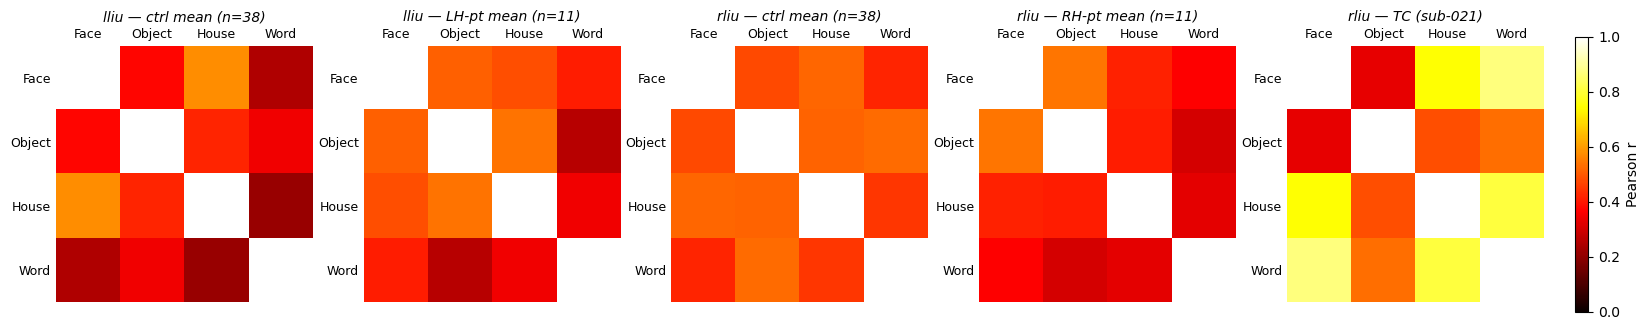

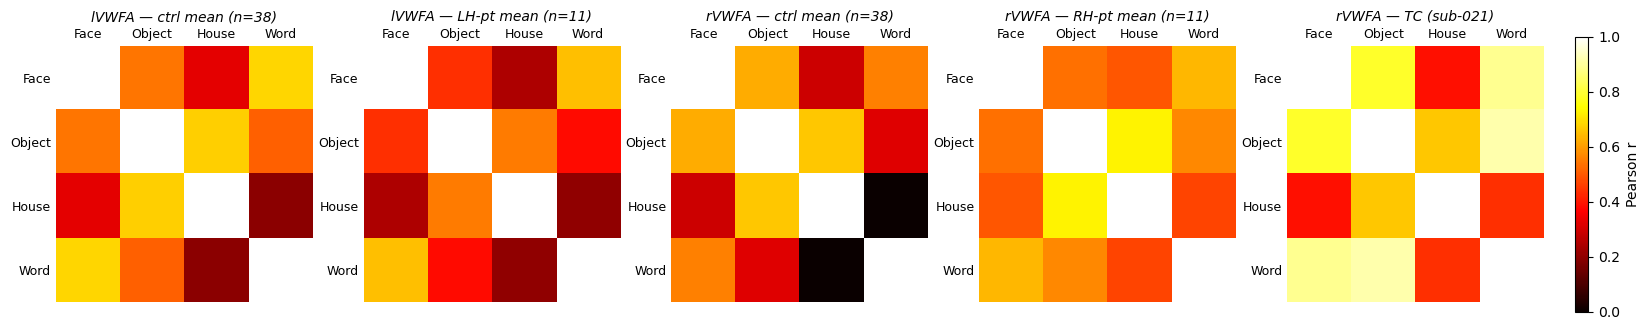

In [47]:
CATS4 = ['face', 'object', 'house', 'word']

def rdm(subj_pw):
    M = np.full((4, 4), np.nan)
    for i, a in enumerate(CATS4):
        for j, b in enumerate(CATS4):
            if i == j:
                M[i, j] = 1.0
                continue
            hit = subj_pw[subj_pw['pair'].isin([f'{a}-{b}', f'{b}-{a}'])]
            if len(hit):
                M[i, j] = np.tanh(hit['fisher_r'].iloc[0])
    return M

def mean_rdm(df, category, hemi, subjects):
    """Average RDM across subjects (each subject's RDM computed first, then averaged)."""
    rdms = []
    for s in subjects:
        sdf = df[(df['subject_id'] == s) & (df['category'] == category) & (df['hemi'] == hemi)]
        if len(sdf) == 6:
            rdms.append(rdm(sdf))
    if not rdms:
        return np.full((4, 4), np.nan), 0
    return np.nanmean(np.stack(rdms), axis=0), len(rdms)

def plot_rdm_5panel(roi, focal_sub, focal_hemi, fname):
    """1×5 layout: ctrl LH mean | LH-pt mean | ctrl RH mean | RH-pt mean | focal pt single."""
    ctrl_lh, n_lh = mean_rdm(ctrl_pw, roi, 'l', ctrl_subs)
    ctrl_rh, n_rh = mean_rdm(ctrl_pw, roi, 'r', ctrl_subs)

    # Patient groups by intact hemi
    lh_pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == 'l']  # R-resection
    rh_pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == 'r']  # L-resection
    lh_pt_rdm, n_lh_pt = mean_rdm(pt_pw, roi, 'l', lh_pt_subs)
    rh_pt_rdm, n_rh_pt = mean_rdm(pt_pw, roi, 'r', rh_pt_subs)

    # Focal patient (TC = sub-021, intact RH)
    focal_q = pt_pw[(pt_pw['subject_id'] == focal_sub) &
                    (pt_pw['category'] == roi) & (pt_pw['hemi'] == focal_hemi)]
    focal_rdm = rdm(focal_q) if len(focal_q) == 6 else np.full((4, 4), np.nan)
    focal_label = LIU_CODES.get(focal_sub, focal_sub.replace('sub-', ''))

    short = roi.split('_')[-1]
    fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
    panels = [
        (ctrl_lh,    f'l{short} — ctrl mean (n={n_lh})'),
        (lh_pt_rdm,  f'l{short} — LH-pt mean (n={n_lh_pt})'),
        (ctrl_rh,    f'r{short} — ctrl mean (n={n_rh})'),
        (rh_pt_rdm,  f'r{short} — RH-pt mean (n={n_rh_pt})'),
        (focal_rdm,  f'{focal_hemi}{short} — {focal_label} ({focal_sub})'),
    ]
    last_im = None
    for ax, (M, ttl) in zip(axes, panels):
        im = ax.imshow(M, cmap='hot', vmin=0, vmax=1, aspect='equal')
        last_im = im
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(['Face', 'Object', 'House', 'Word'], fontsize=9)
        ax.set_yticklabels(['Face', 'Object', 'House', 'Word'], fontsize=9)
        ax.xaxis.tick_top()
        ax.set_title(ttl, fontsize=10, style='italic', pad=18)
        ax.tick_params(length=0)
        for sp in ax.spines.values(): sp.set_visible(False)
    fig.colorbar(last_im, ax=axes, fraction=0.020, pad=0.02, shrink=0.85, label='Pearson r')
    plt.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

for roi, fname in [('word_pSTG_liu', 'liu_exact_fig3AB_pSTG.png'),
                   ('word_VWFA',     'liu_exact_fig3AB_VWFA.png')]:
    plot_rdm_5panel(roi, 'sub-021', 'r', fname)


## 7. Fig 3D — Per-ROI Fisher-z boxplots

Control distributions as boxes; patient markers at intact hemi. Word ROIs plotted at preferred hemi ("folded").

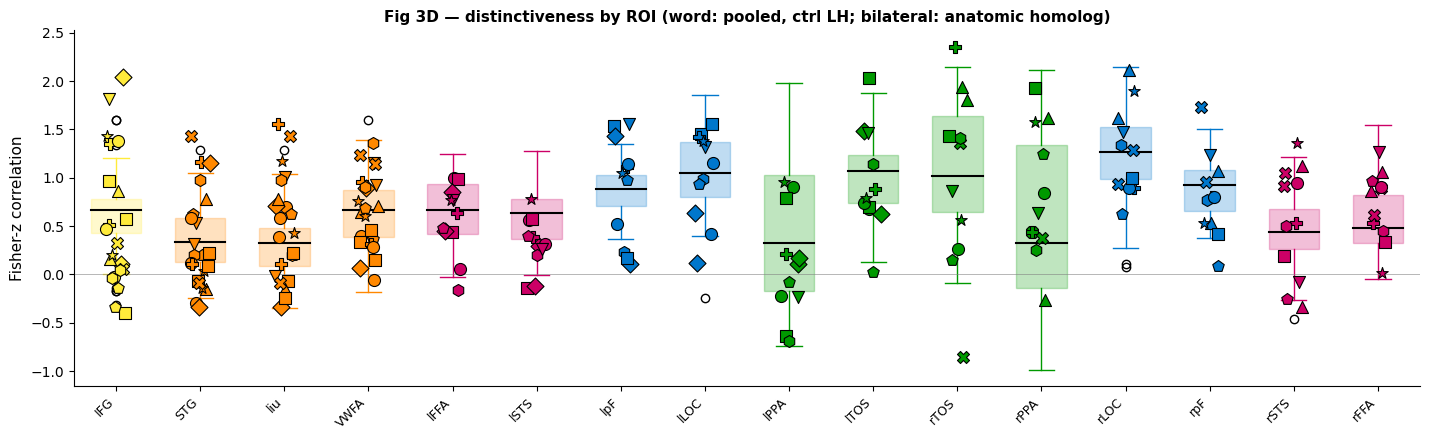

In [48]:
# Word ROIs (VWFA, STG, pSTG_liu, IFG) → single pooled panel each, ctrl LH anchor.
# Bilateral ROIs (face/house/object) → per-hemi anatomic homolog.
ROI_ORDER = [
    ('word_IFG',      'pooled'),
    ('word_STG',      'pooled'),
    ('word_pSTG_liu', 'pooled'),
    ('word_VWFA',     'pooled'),
    ('face_FFA',      'l'),    ('face_STS',   'l'),
    ('object_pF',     'l'),    ('object_LOC', 'l'),
    ('house_PPA',     'l'),    ('house_TOS',  'l'),
    ('house_TOS',     'r'),    ('house_PPA',  'r'),
    ('object_LOC',    'r'),    ('object_pF',  'r'),
    ('face_STS',      'r'),    ('face_FFA',   'r'),
]

def ctrl_hemi(hspec):
    """Pooled (word) → ctrl LH (Liu anchor); else → hspec (anatomic homolog)."""
    return 'l' if hspec == 'pooled' else hspec

def pt_panel_match(sub, hspec):
    """Pooled panels accept any patient (plotted at intact hemi).
    Bilateral panels: only patients whose intact hemi matches."""
    pt_h = pt_intact_hemi(sub)
    if pt_h is None: return False, None
    if hspec == 'pooled': return True, pt_h
    return pt_h == hspec, pt_h

def roi_label(roi, hspec):
    s = roi.split('_')[-1]
    return s if hspec == 'pooled' else f'{hspec}{s}'

ROI_CAT_COLOR = {
    'word_STG':   '#ff8800', 'word_VWFA':  '#ff8800', 'word_pSTG_liu': '#ff8800',
    'word_IFG':   '#ffeb3b',
    'face_FFA':   '#cc0066', 'face_STS':   '#cc0066',
    'object_pF':  '#0077cc', 'object_LOC': '#0077cc',
    'house_PPA':  '#009900', 'house_TOS':  '#009900',
    'evc':        'gray',
}

_mc = ['o', 's', 'D', '^', 'v', 'P', '*', 'X', 'p', 'h']
PT_MARKERS = {s: _mc[i % len(_mc)] for i, s in enumerate(otc_subs)}

def get_distinct(df, sub, roi, hemi):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == hemi)]
    return m['liu_distinctiveness'].values[0] if len(m) else np.nan

n = len(ROI_ORDER)
fig, ax = plt.subplots(figsize=(max(14, n * 0.9), 4.5))
rng = np.random.RandomState(42)
JITTER = 0.12

for xi, (roi, hspec) in enumerate(ROI_ORDER):
    color  = ROI_CAT_COLOR[roi]
    ch = ctrl_hemi(hspec)
    cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == ch)]['liu_distinctiveness'].dropna().values
    if len(cvals) == 0: continue
    ax.boxplot(cvals, positions=[xi], widths=0.6, patch_artist=True,
               medianprops={'color': 'black', 'lw': 1.5},
               whiskerprops={'color': color}, capprops={'color': color},
               boxprops={'facecolor': color, 'alpha': 0.25, 'edgecolor': color})
    for sub in otc_subs:
        ok, pt_h = pt_panel_match(sub, hspec)
        if not ok: continue
        val = get_distinct(pt_le, sub, roi, pt_h)
        if np.isnan(val): continue
        ax.scatter(xi + rng.uniform(-JITTER, JITTER), val,
                   marker=PT_MARKERS[sub], s=75, zorder=5,
                   edgecolors='black', linewidth=0.8, facecolors=color)

ax.set_xticks(np.arange(n))
ax.set_xticklabels([roi_label(c, h) for c, h in ROI_ORDER], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Fisher-z correlation', fontsize=11)
ax.axhline(0, color='gray', lw=0.4)
ax.set_title('Fig 3D — distinctiveness by ROI (word: pooled, ctrl LH; bilateral: anatomic homolog)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig3D.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Fig 3E — Per-ROI Crawford *t* (with FDR)

FDR method controlled by `FDR_METHOD` in setup. `None` disables correction.

Significant (raw α=.05):     28 / 220
Significant (within-ROI FDR-bh): 8 / 220
n_ctrl per ROI: min=37, max=60
Critical t (uncorrected, df=36): ±2.028



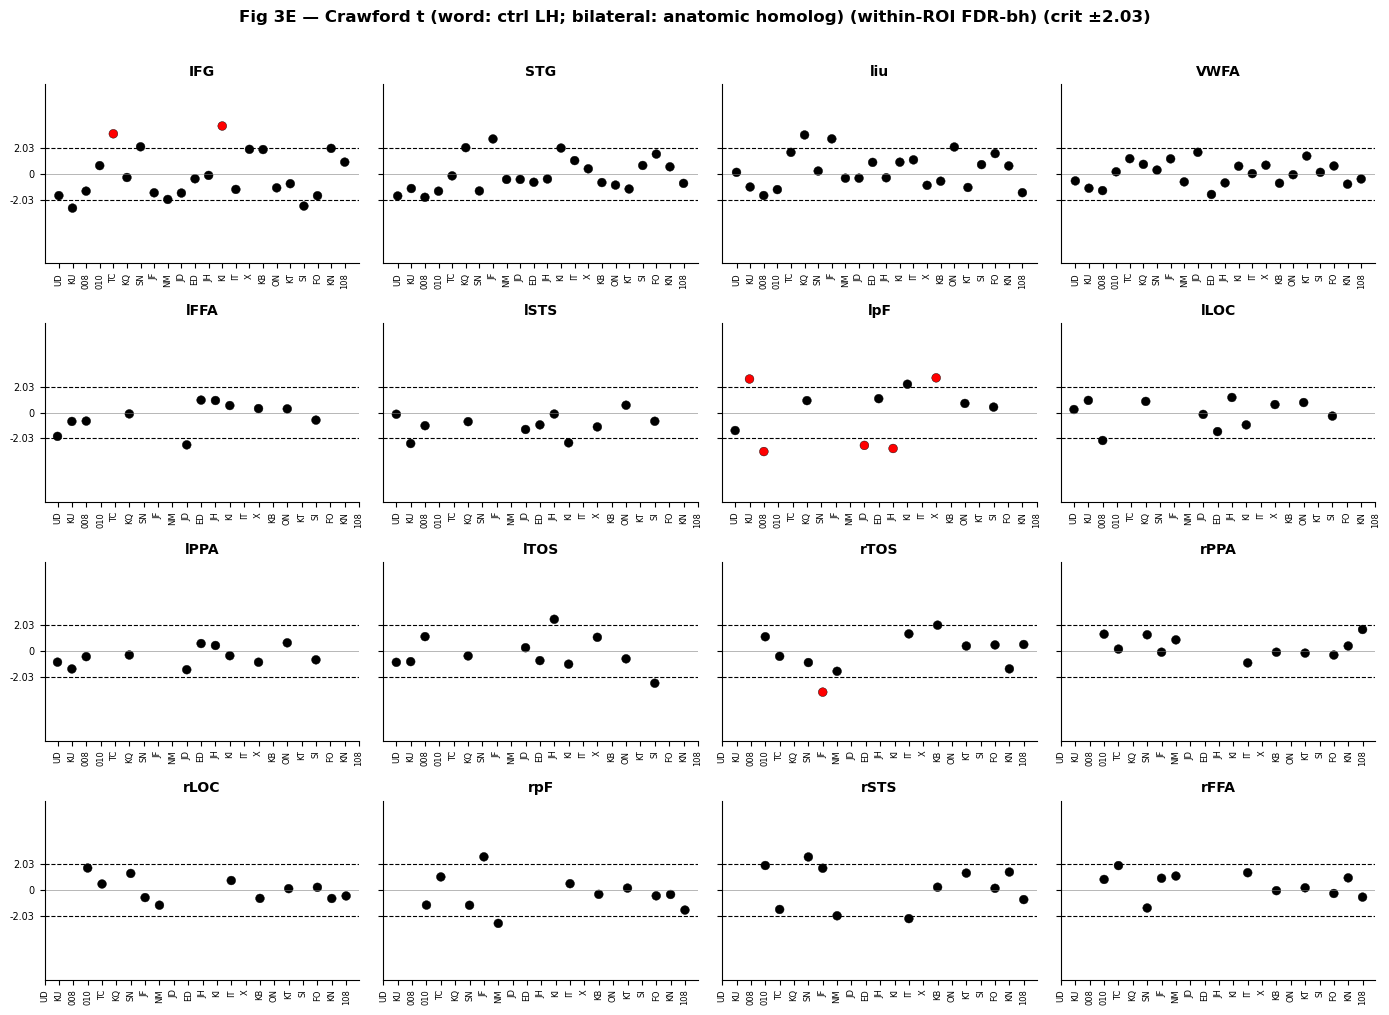

In [49]:
t_mat = np.full((n, len(otc_subs)), np.nan)
p_mat = np.full((n, len(otc_subs)), np.nan)
n_ctrls_roi = np.zeros(n, dtype=int)

for r, (roi, hspec) in enumerate(ROI_ORDER):
    ch = ctrl_hemi(hspec)
    cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == ch)]['liu_distinctiveness'].dropna().values
    n_ctrls_roi[r] = len(cvals)
    if len(cvals) < 3: continue
    for p_, sub in enumerate(otc_subs):
        ok, pt_h = pt_panel_match(sub, hspec)
        if not ok: continue
        val = get_distinct(pt_le, sub, roi, pt_h)
        if np.isnan(val): continue
        t_mat[r, p_], p_mat[r, p_] = crawford(val, cvals)

min_df = max(int(n_ctrls_roi[n_ctrls_roi > 0].min()) - 1, 1)
crit_3E = float(tdist.ppf(0.975, df=min_df))

# FDR scoped WITHIN each ROI (across patients), not globally.
sig_mat = np.abs(t_mat) > crit_3E
if FDR_METHOD is not None:
    sig_mat = np.zeros_like(t_mat, dtype=bool)
    for r in range(n):
        sig_mat[r, :] = fdr_correct(p_mat[r, :], method=FDR_METHOD)
    n_raw = int((np.abs(t_mat) > crit_3E).sum())
    n_fdr = int(sig_mat.sum())
    print(f'Significant (raw α=.05):     {n_raw} / {(~np.isnan(t_mat)).sum()}')
    print(f'Significant (within-ROI FDR-{FDR_METHOD}): {n_fdr} / {(~np.isnan(t_mat)).sum()}')
else:
    print(f'Significant (uncorrected): {int(sig_mat.sum())} / {(~np.isnan(t_mat)).sum()}')

print(f'n_ctrl per ROI: min={n_ctrls_roi[n_ctrls_roi>0].min()}, max={n_ctrls_roi.max()}')
print(f'Critical t (uncorrected, df={min_df}): ±{crit_3E:.3f}\n')

n_cols_3E = 4
n_rows_3E = int(np.ceil(n / n_cols_3E))
fig, axes = plt.subplots(n_rows_3E, n_cols_3E, figsize=(3.5 * n_cols_3E, 2.5 * n_rows_3E), sharey=True)
axes = axes.flatten()
pt_labels = [SUB_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
for r, (roi, hspec) in enumerate(ROI_ORDER):
    ax = axes[r]
    xs = np.arange(len(otc_subs))
    tv = t_mat[r]
    colors = ['red' if sig_mat[r, i] else 'black' for i in range(len(otc_subs))]
    ax.scatter(xs, tv, s=40, c=colors, edgecolors='k', linewidth=0.3)
    ax.axhline( crit_3E, color='k', lw=0.8, ls='--')
    ax.axhline(-crit_3E, color='k', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-7, 7); ax.set_yticks([-crit_3E, 0, crit_3E])
    ax.set_yticklabels([f'{-crit_3E:.2f}', '0', f'{crit_3E:.2f}'], fontsize=7)
    ax.set_xticks(xs); ax.set_xticklabels(pt_labels, rotation=90, fontsize=6)
    ax.set_title(roi_label(roi, hspec), fontsize=10, fontweight='bold')
for r in range(n, len(axes)):
    axes[r].axis('off')
suffix = f' (within-ROI FDR-{FDR_METHOD})' if FDR_METHOD else ' (uncorrected)'
plt.suptitle(f'Fig 3E — Crawford t (word: ctrl LH; bilateral: anatomic homolog){suffix} (crit ±{crit_3E:.2f})',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig3E.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Fig 3E′ — Per-category-pair Crawford *t* (with FDR)

Preferred vs each non-preferred category, per ROI × patient. 3 t-values per cell.

Significant (raw):       71 / 660
Significant (FDR-bh):  2 / 660


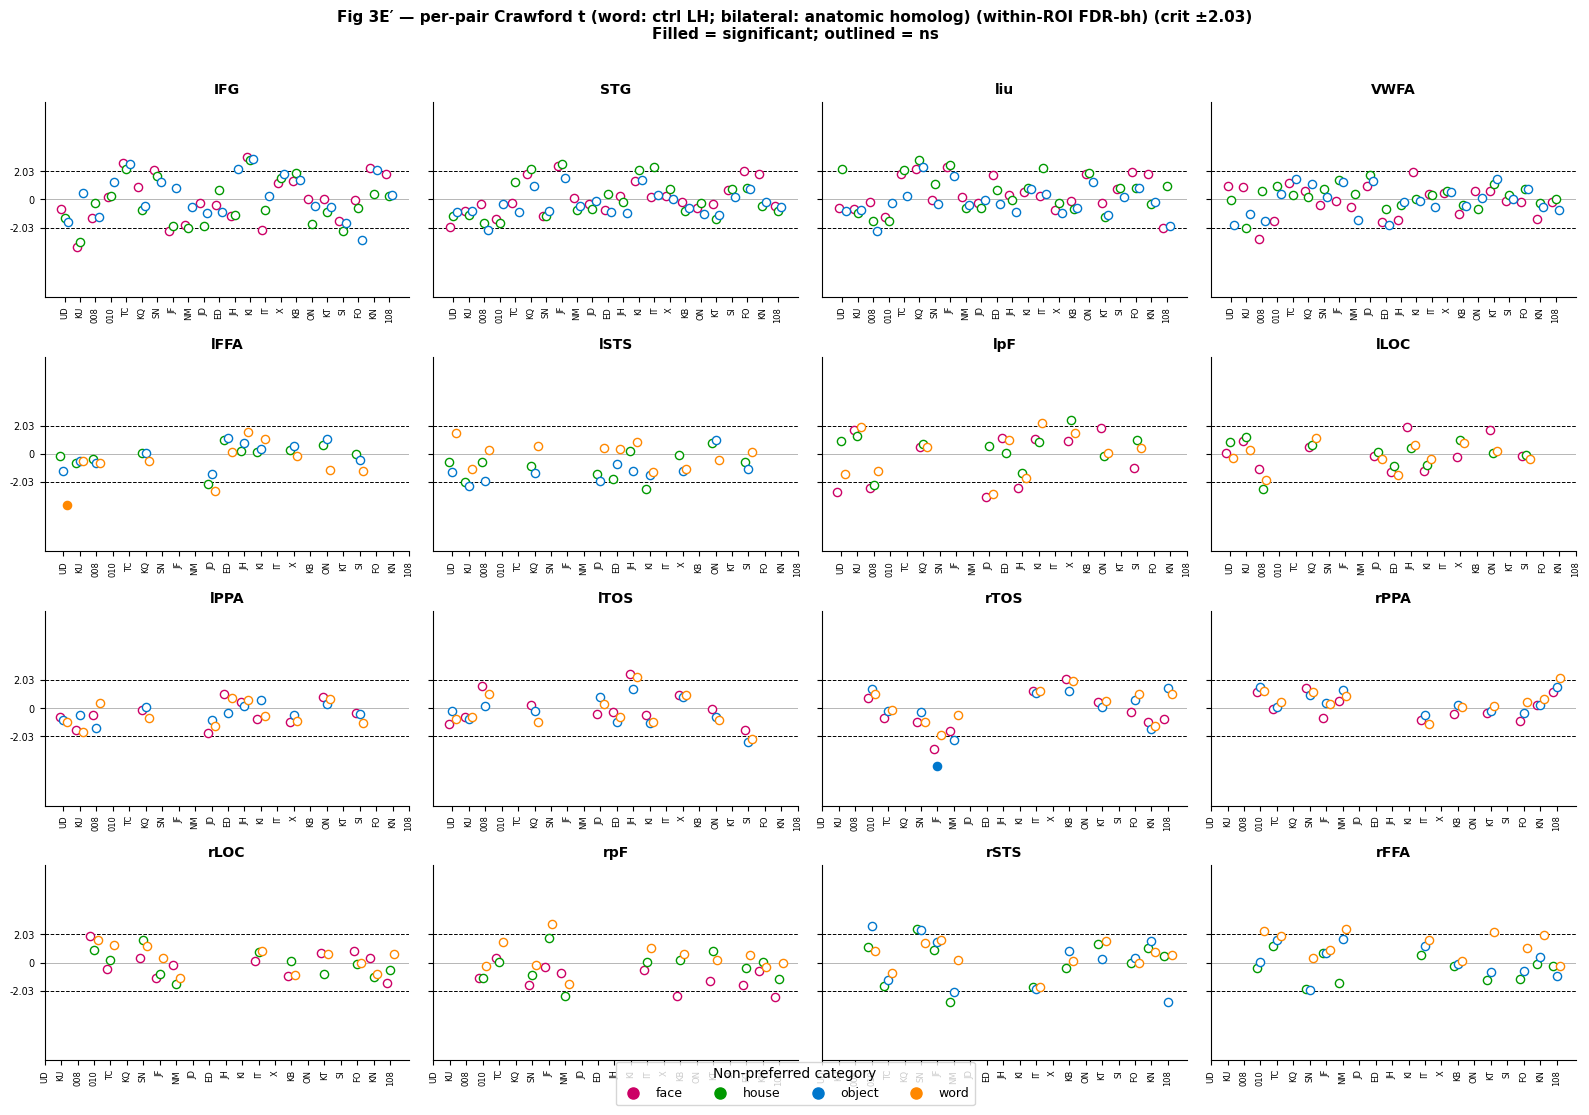

In [50]:
PARENT = {'face_FFA': 'face', 'face_STS': 'face',
          'house_PPA': 'house', 'house_TOS': 'house',
          'object_pF': 'object', 'object_LOC': 'object',
          'word_VWFA': 'word', 'word_STG': 'word', 'word_pSTG_liu': 'word',
          'word_IFG': 'word'}
CAT_COLOR = {'face': '#cc0066', 'house': '#009900', 'object': '#0077cc', 'word': '#ff8800'}

def get_pair_fz(df, sub, cat, hemi, pair_str):
    a, b = pair_str.split('-')
    m = df[(df['subject_id'] == sub) & (df['category'] == cat) & (df['hemi'] == hemi) &
           (df['pair'].isin([f'{a}-{b}', f'{b}-{a}']))]
    return m['fisher_r'].iloc[0] if len(m) else np.nan

NONPREF_CATS = {roi: [c for c in ['face', 'house', 'object', 'word'] if c != PARENT[roi]]
                for roi, _ in ROI_ORDER}

t_pair = np.full((n, len(otc_subs), 3), np.nan)
p_pair = np.full((n, len(otc_subs), 3), np.nan)
n_ctrl_pair = np.zeros((n, 3), dtype=int)

for r, (roi, hspec) in enumerate(ROI_ORDER):
    pref = PARENT[roi]
    ch = ctrl_hemi(hspec)
    for k, nonpref in enumerate(NONPREF_CATS[roi]):
        pair_str = f'{pref}-{nonpref}'
        cvals = np.array([get_pair_fz(ctrl_pw, s, roi, ch, pair_str) for s in ctrl_subs])
        cvals = cvals[~np.isnan(cvals)]
        n_ctrl_pair[r, k] = len(cvals)
        if len(cvals) < 3: continue
        for p, sub in enumerate(otc_subs):
            ok, pt_h = pt_panel_match(sub, hspec)
            if not ok: continue
            x = get_pair_fz(pt_pw, sub, roi, pt_h, pair_str)
            if np.isnan(x): continue
            t_pair[r, p, k], p_pair[r, p, k] = crawford(x, cvals)

min_df_3E = max(int(n_ctrl_pair[n_ctrl_pair > 0].min()) - 1, 1)
crit_3Ep = float(tdist.ppf(0.975, df=min_df_3E))

sig_pair = np.abs(t_pair) > crit_3Ep
if FDR_METHOD is not None:
    sig_pair = np.zeros_like(t_pair, dtype=bool)
    for r in range(n):
        roi_p = p_pair[r, :, :].flatten()
        sig_pair[r, :, :] = fdr_correct(roi_p, method=FDR_METHOD).reshape(p_pair[r].shape)
    print(f'Significant (raw):       {int((np.abs(t_pair) > crit_3Ep).sum())} / {(~np.isnan(t_pair)).sum()}')
    print(f'Significant (FDR-{FDR_METHOD}):  {int(sig_pair.sum())} / {(~np.isnan(t_pair)).sum()}')

n_cols_pair = 4
n_rows_pair = int(np.ceil(n / n_cols_pair))
fig, axes = plt.subplots(n_rows_pair, n_cols_pair, figsize=(4 * n_cols_pair, 2.7 * n_rows_pair), sharey=True)
axes = axes.flatten()
pt_labels = [SUB_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
offsets_3k = [-0.22, 0, 0.22]

for r, (roi, hspec) in enumerate(ROI_ORDER):
    ax = axes[r]
    xs_base = np.arange(len(otc_subs))
    for k, nonpref in enumerate(NONPREF_CATS[roi]):
        xs = xs_base + offsets_3k[k]
        for i in range(len(otc_subs)):
            tv = t_pair[r, i, k]
            if np.isnan(tv): continue
            is_sig = sig_pair[r, i, k]
            ax.scatter(xs[i], tv, s=35,
                       facecolors=CAT_COLOR[nonpref] if is_sig else 'white',
                       edgecolors=CAT_COLOR[nonpref], linewidth=1.0, zorder=3)
    ax.axhline( crit_3Ep, color='k', lw=0.7, ls='--')
    ax.axhline(-crit_3Ep, color='k', lw=0.7, ls='--')
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-7, 7)
    ax.set_yticks([-crit_3Ep, 0, crit_3Ep])
    ax.set_yticklabels([f'{-crit_3Ep:.2f}', '0', f'{crit_3Ep:.2f}'], fontsize=7)
    ax.set_xticks(xs_base); ax.set_xticklabels(pt_labels, rotation=90, fontsize=6)
    ax.set_title(roi_label(roi, hspec), fontsize=10, fontweight='bold')

for r in range(n, len(axes)):
    axes[r].axis('off')

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor=c, markersize=8, label=cat)
                  for cat, c in CAT_COLOR.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.01), title='Non-preferred category')

suffix = f' (within-ROI FDR-{FDR_METHOD})' if FDR_METHOD else ' (uncorrected)'
plt.suptitle(f'Fig 3E\u2032 — per-pair Crawford t (word: ctrl LH; bilateral: anatomic homolog){suffix} '
             f'(crit \u00b1{crit_3Ep:.2f})\nFilled = significant; outlined = ns',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig3E_pairs.png', dpi=300, bbox_inches='tight')
plt.show()


## 10. Sum-selectivity (Ayzenberg 2023)

Bootstrapped 95% CI of control mean (10,000 resamples with replacement).
Patient value flagged if outside CI.

  face LH: n_pt=11, n_ct=38, t=-0.34, p=0.739, d=-0.15
  face RH: n_pt=11, n_ct=38, t=-0.13, p=0.898, d=-0.04
  house LH: n_pt=11, n_ct=38, t=-0.27, p=0.789, d=-0.10
  house RH: n_pt=11, n_ct=38, t=-1.37, p=0.194, d=-0.55
  object LH: n_pt=11, n_ct=38, t=-1.98, p=0.073, d=-1.08
  object RH: n_pt=11, n_ct=38, t=-1.44, p=0.174, d=-0.63
  word LH: n_pt=10, n_ct=36, t=-1.02, p=0.322, d=-0.31
  word RH: n_pt=10, n_ct=38, t=+1.67, p=0.107, d=+0.45


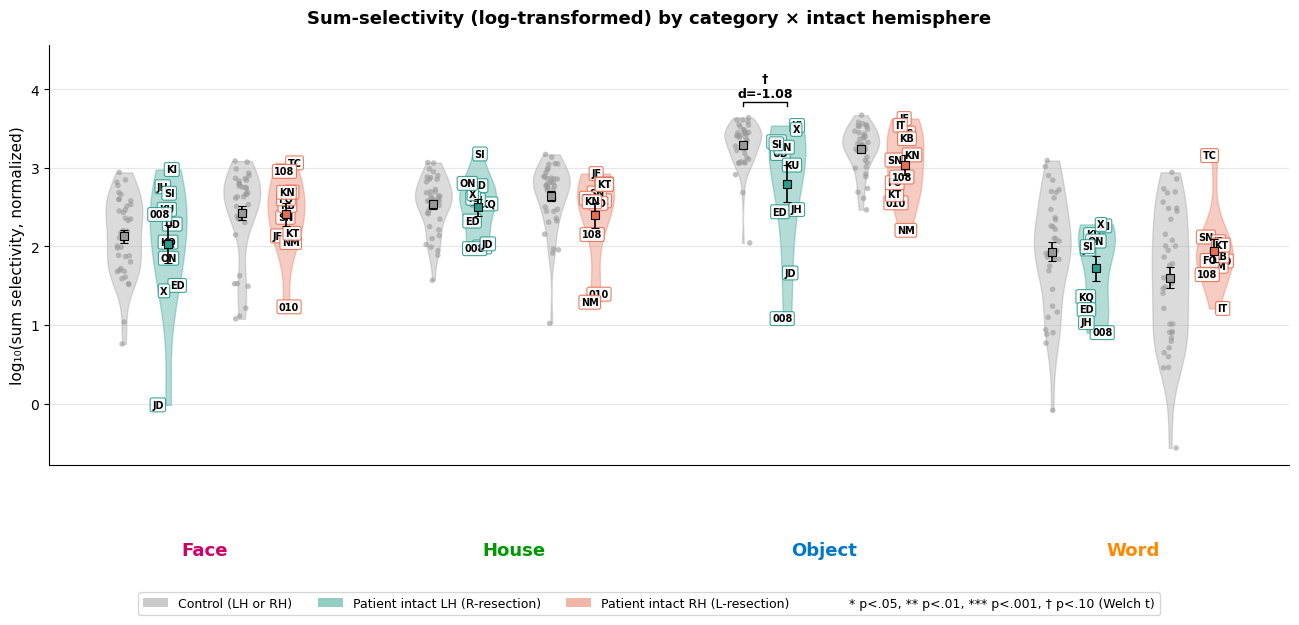

In [51]:
from scipy import stats

CAT_SUBROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu'],
}
CAT_COLORS_SS = {'face': '#cc0066', 'house': '#009900',
                 'object': '#0077cc', 'word': '#ff8800'}

CTRL_L_COLOR = '#999999'
CTRL_R_COLOR = '#999999'
PT_L_COLOR   = '#2a9d8f'
PT_R_COLOR   = '#e76f51'

def collapse_log_selec(df, subject, category, hemi):
    vals = df[(df['subject_id'] == subject) &
              (df['category'].isin(CAT_SUBROIS[category])) &
              (df['hemi'] == hemi)]['sum_selec_norm'].dropna().values
    vals = vals[vals > 0]
    return np.mean(np.log10(vals)) if len(vals) else np.nan

def short_name(sub):
    return SUB_CODES.get(sub, sub.replace('sub-', ''))

def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    pooled = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled

def build_table(df, subjects):
    rows = []
    for s in subjects:
        for cat in CAT_SUBROIS:
            for h in ('l', 'r'):
                v = collapse_log_selec(df, s, cat, h)
                if not np.isnan(v):
                    rows.append({'subject_id': s, 'category': cat, 'hemi': h, 'val': v})
    return pd.DataFrame(rows)

ctrl_selec = build_table(ctrl_le, ctrl_subs)
pt_selec   = build_table(pt_le,   otc_subs)

intact_lookup = dict(zip(pt_le['subject_id'], pt_le['intact_hemi']))
pt_selec['intact_hemi'] = pt_selec['subject_id'].map(intact_lookup)
pt_selec = pt_selec[
    ((pt_selec['intact_hemi'] == 'left')  & (pt_selec['hemi'] == 'l')) |
    ((pt_selec['intact_hemi'] == 'right') & (pt_selec['hemi'] == 'r'))
]

CATS_PANEL = ['face', 'house', 'object', 'word']

INTRA   = 0.6
INTER   = 1.0
CAT_GAP = 2.0
positions_within = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]
cat_width = positions_within[-1]

fig, ax = plt.subplots(figsize=(16, 6))
RNG_SS = np.random.RandomState(42)

all_ticks, all_labels, cat_centers = [], [], []

for ci, cat in enumerate(CATS_PANEL):
    base = ci * (cat_width + CAT_GAP)
    positions = [base + p for p in positions_within]
    cat_centers.append(np.mean(positions))

    cl = ctrl_selec[(ctrl_selec['category'] == cat) & (ctrl_selec['hemi'] == 'l')]['val'].values
    cr = ctrl_selec[(ctrl_selec['category'] == cat) & (ctrl_selec['hemi'] == 'r')]['val'].values
    pl = pt_selec[(pt_selec['category'] == cat)   & (pt_selec['hemi']   == 'l')]
    pr = pt_selec[(pt_selec['category'] == cat)   & (pt_selec['hemi']   == 'r')]

    groups = [
        (cl,                 positions[0], CTRL_L_COLOR, 'violin', None),
        (pl['val'].values,   positions[1], PT_L_COLOR,   'labels', pl['subject_id'].values),
        (cr,                 positions[2], CTRL_R_COLOR, 'violin', None),
        (pr['val'].values,   positions[3], PT_R_COLOR,   'labels', pr['subject_id'].values),
    ]

    for vals, pos, col, kind, subs in groups:
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0: continue
        if len(vals) >= 2:
            parts = ax.violinplot([vals], positions=[pos], widths=0.5,
                                  showmeans=False, showmedians=False, showextrema=False)
            for b in parts['bodies']:
                b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor(col)
        if kind == 'violin':
            jit = RNG_SS.uniform(-0.1, 0.1, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=col, alpha=0.6, s=16, edgecolors='none', zorder=3)
        else:
            for v, sub in zip(vals, subs):
                jit = RNG_SS.uniform(-0.15, 0.15)
                ax.annotate(short_name(sub), (pos + jit, v),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=col, alpha=0.9, linewidth=0.8),
                            zorder=4)
        ax.errorbar(pos, np.mean(vals),
                    yerr=np.std(vals)/np.sqrt(max(len(vals), 1)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=col, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

# Group-level significance: Welch t + Cohen\'s d
    for pos_ctrl, pos_pt, pt_vals, ctrl_vals in [
        (positions[0], positions[1], pl['val'].values, cl),
        (positions[2], positions[3], pr['val'].values, cr),
    ]:
        pt_vals = pt_vals[~np.isnan(pt_vals)]
        ctrl_vals = ctrl_vals[~np.isnan(ctrl_vals)]
        if len(pt_vals) < 2 or len(ctrl_vals) < 3: continue
        t, p = stats.ttest_ind(pt_vals, ctrl_vals, equal_var=False)
        d = cohens_d(pt_vals, ctrl_vals)
        hemi_label = 'LH' if pos_pt == positions[1] else 'RH'
        print(f'  {cat} {hemi_label}: n_pt={len(pt_vals)}, n_ct={len(ctrl_vals)}, '
              f't={t:+.2f}, p={p:.3f}, d={d:+.2f}')
        if p < 0.05:
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        elif p < 0.10:
            sig = '\u2020'
        else:
            continue
        y_top = max(np.max(pt_vals), np.max(ctrl_vals))
        y_br = y_top + 0.15
        ax.plot([pos_ctrl, pos_ctrl, pos_pt, pos_pt],
                [y_br, y_br + 0.05, y_br + 0.05, y_br],
                color='black', linewidth=1, clip_on=False)
        ax.text((pos_ctrl + pos_pt) / 2, y_br + 0.07,
                f'{sig}\nd={d:+.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(all_ticks)
ax.set_xticklabels(all_labels, fontsize=8)
ax.set_ylabel('log\u2081\u2080(sum selectivity, normalized)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for cat, center in zip(CATS_PANEL, cat_centers):
    ax.text(center, -0.18, cat.title(), fontsize=13, fontweight='bold',
            color=CAT_COLORS_SS[cat], ha='center', va='top',
            transform=ax.get_xaxis_transform())

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax + 0.5)

legend_elements = [
    Patch(facecolor=CTRL_L_COLOR, alpha=0.5, label='Control (LH or RH)'),
    Patch(facecolor=PT_L_COLOR,   alpha=0.5, label='Patient intact LH (R-resection)'),
    Patch(facecolor=PT_R_COLOR,   alpha=0.5, label='Patient intact RH (L-resection)'),
    Line2D([0], [0], marker='None', linestyle='None',
           label='* p<.05, ** p<.01, *** p<.001, \u2020 p<.10 (Welch t)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Sum-selectivity (log-transformed) by category \u00d7 intact hemisphere',
             fontsize=13, fontweight='bold', y=0.98)
plt.subplots_adjust(bottom=0.22, top=0.92)
plt.savefig(FIG_DIR / 'liu_exact_sum_selectivity.png', dpi=300, bbox_inches='tight')
plt.show()


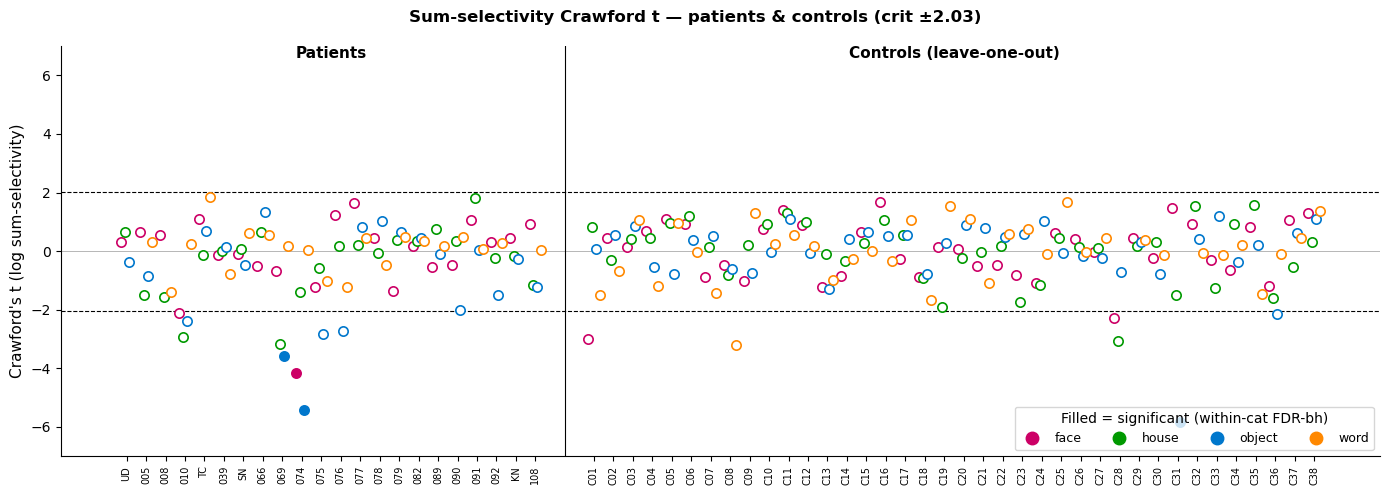

In [52]:
CAT_SUBROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu'],
}
CATS_PANEL = ['face', 'house', 'object', 'word']
CAT_COLORS_SS = {'face': '#cc0066', 'house': '#009900',
                 'object': '#0077cc', 'word': '#ff8800'}

def get_sel(df, sub, cat, hemi):
    vals = df[(df['subject_id']==sub) & (df['category'].isin(CAT_SUBROIS[cat])) &
              (df['hemi']==hemi)]['sum_selec_norm'].dropna().values
    vals = vals[vals > 0]
    return np.mean(np.log10(vals)) if len(vals) else np.nan

N_PT = len(otc_subs)
N_CT = len(ctrl_subs)

# Patient Crawford t at intact hemi
t_pt_flat = {cat: np.full(N_PT, np.nan) for cat in CATS_PANEL}
p_pt_flat = {cat: np.full(N_PT, np.nan) for cat in CATS_PANEL}
for cat in CATS_PANEL:
    for pi, sub in enumerate(otc_subs):
        pt_h = pt_intact_hemi(sub)
        if pt_h is None: continue
        cvals = np.array([get_sel(ctrl_le, s, cat, pt_h) for s in ctrl_subs])
        cvals = cvals[~np.isnan(cvals)]
        if len(cvals) < 3: continue
        x = get_sel(pt_le, sub, cat, pt_h)
        if np.isnan(x): continue
        t_pt_flat[cat][pi], p_pt_flat[cat][pi] = crawford(x, cvals)

# Control leave-one-out at LH
t_ctrl_sel = {cat: np.full(N_CT, np.nan) for cat in CATS_PANEL}
p_ctrl_sel = {cat: np.full(N_CT, np.nan) for cat in CATS_PANEL}
for cat in CATS_PANEL:
    cvals_all = np.array([get_sel(ctrl_le, s, cat, 'l') for s in ctrl_subs])
    for ci in range(N_CT):
        if np.isnan(cvals_all[ci]): continue
        others = np.delete(cvals_all, ci)
        others = others[~np.isnan(others)]
        if len(others) < 3: continue
        t_ctrl_sel[cat][ci], p_ctrl_sel[cat][ci] = crawford(cvals_all[ci], others)

min_df_sel = N_CT - 1
crit_sel = float(tdist.ppf(0.975, df=min_df_sel))

# Within-cat FDR across patients + controls
sig_pt_flat   = {cat: np.zeros(N_PT, bool) for cat in CATS_PANEL}
sig_ctrl_flat = {cat: np.zeros(N_CT, bool) for cat in CATS_PANEL}
if FDR_METHOD is not None:
    for cat in CATS_PANEL:
        all_p = np.concatenate([p_pt_flat[cat], p_ctrl_sel[cat]])
        all_sig = fdr_correct(all_p, method=FDR_METHOD)
        sig_pt_flat[cat]   = all_sig[:N_PT]
        sig_ctrl_flat[cat] = all_sig[N_PT:]
else:
    for cat in CATS_PANEL:
        sig_pt_flat[cat]   = np.abs(t_pt_flat[cat])  > crit_sel
        sig_ctrl_flat[cat] = np.abs(t_ctrl_sel[cat]) > crit_sel

fig, ax = plt.subplots(figsize=(14, 5))
CAT_OFFSETS = {'face': -0.3, 'house': -0.1, 'object': 0.1, 'word': 0.3}
PT_XS = np.arange(N_PT)
CT_XS = np.arange(N_CT) + N_PT + 2

pt_labels = [LIU_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
ctrl_labels = [f'C{i+1:02d}' for i in range(N_CT)]

for cat in CATS_PANEL:
    color = CAT_COLORS_SS[cat]
    off = CAT_OFFSETS[cat]
    for pi in range(N_PT):
        tv = t_pt_flat[cat][pi]
        if np.isnan(tv): continue
        is_sig = sig_pt_flat[cat][pi]
        ax.scatter(PT_XS[pi] + off, tv, s=45,
                   facecolors=color if is_sig else 'white',
                   edgecolors=color, linewidth=1.2, zorder=3)
    for ci in range(N_CT):
        tv = t_ctrl_sel[cat][ci]
        if np.isnan(tv): continue
        is_sig = sig_ctrl_flat[cat][ci]
        ax.scatter(CT_XS[ci] + off, tv, s=45,
                   facecolors=color if is_sig else 'white',
                   edgecolors=color, linewidth=1.2, zorder=3)

ax.axhline( crit_sel, color='k', lw=0.8, ls='--')
ax.axhline(-crit_sel, color='k', lw=0.8, ls='--')
ax.axhline(0, color='gray', lw=0.4)
ax.axvline(N_PT + 0.5, color='k', lw=0.8)
ax.set_ylim(-7, 7)

ax.set_xticks(list(PT_XS) + list(CT_XS))
ax.set_xticklabels(pt_labels + ctrl_labels, rotation=90, fontsize=7)
ax.set_ylabel("Crawford's t (log sum-selectivity)", fontsize=11)

ax.text(np.mean(PT_XS), 6.6, 'Patients',
        ha='center', fontsize=11, fontweight='bold')
ax.text(np.mean(CT_XS), 6.6, 'Controls (leave-one-out)',
        ha='center', fontsize=11, fontweight='bold')

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor=c, markersize=9, label=cat)
                  for cat, c in CAT_COLORS_SS.items()]
suffix = f' (within-cat FDR-{FDR_METHOD})' if FDR_METHOD else ' (uncorrected)'
ax.legend(handles=legend_handles, loc='lower right', ncol=4, fontsize=9,
          title=f'Filled = significant{suffix}')

plt.suptitle(f"Sum-selectivity Crawford t — patients & controls (crit ±{crit_sel:.2f})",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_sum_selec_crawford.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Validation summary

In [53]:
print('=== Sphere voxel counts (expect ~175 at 2mm) ===')
summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates()
print(summary.groupby('category')['n_sphere_voxels'].agg(['mean', 'min', 'max']).round(0))

print('\n=== TC (sub-021) word ROIs at intact RH vs control LH distribution (Liu anchor) ===')
for roi in ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG']:
    tc = pt_le[(pt_le['subject_id'] == 'sub-021') & (pt_le['category'] == roi) &
               (pt_le['hemi'] == 'r')]['liu_distinctiveness'].values
    cv = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == 'l')]['liu_distinctiveness'].dropna().values
    if len(tc) and len(cv):
        t, p = crawford(tc[0], cv)
        print(f'  {roi:15s}: TC={tc[0]:.3f}, ctrl LH M={cv.mean():.3f} (SD={cv.std():.3f}), '
              f't={t:+.2f}, p={p:.3f}')

print('\n=== ROI × hemi coverage ===')
print(le_summary.groupby(['category', 'hemi'])['subject_id'].nunique().unstack(fill_value=0))


=== Sphere voxel counts (expect ~175 at 2mm) ===
                mean  min  max
category                      
evc            166.0  134  192
face_FFA       168.0  148  192
face_STS       173.0  148  192
house_PPA      170.0  142  192
house_TOS      172.0  148  192
object_LOC     170.0  148  192
object_pF      168.0  148  192
word_IFG       169.0  148  192
word_STG       170.0  138  192
word_VWFA      171.0  148  192
word_pSTG_liu  174.0  148  192

=== TC (sub-021) word ROIs at intact RH vs control LH distribution (Liu anchor) ===
  word_VWFA      : TC=1.148, ctrl LH M=0.637 (SD=0.421), t=+1.18, p=0.245
  word_STG       : TC=0.312, ctrl LH M=0.375 (SD=0.378), t=-0.16, p=0.873
  word_pSTG_liu  : TC=1.011, ctrl LH M=0.341 (SD=0.389), t=+1.68, p=0.102
  word_IFG       : TC=1.815, ctrl LH M=0.621 (SD=0.375), t=+3.13, p=0.003

=== ROI × hemi coverage ===
hemi            l   r
category             
evc            54  53
face_FFA       54  53
face_STS       54  53
house_PPA      54  53
house_

In [54]:
# Sum-selectivity (log): L-res = intact RH, R-res = intact LH
l_res_obj = pt_selec[(pt_selec['category']=='object') & (pt_selec['intact_hemi']=='right')]['val']
r_res_obj = pt_selec[(pt_selec['category']=='object') & (pt_selec['intact_hemi']=='left')]['val']
ctrl_lh = ctrl_selec[(ctrl_selec['category']=='object') & (ctrl_selec['hemi']=='l')]['val']
ctrl_rh = ctrl_selec[(ctrl_selec['category']=='object') & (ctrl_selec['hemi']=='r')]['val']

print(f'L-res obj (intact RH): n={len(l_res_obj)}, mean={l_res_obj.mean():.2f}, vs ctrl RH mean={ctrl_rh.mean():.2f}')
print(f'R-res obj (intact LH): n={len(r_res_obj)}, mean={r_res_obj.mean():.2f}, vs ctrl LH mean={ctrl_lh.mean():.2f}')

# Representation: distinctiveness at intact hemi for object ROIs
for roi in ['object_pF', 'object_LOC']:
    for side, intact_h in [('L-res', 'r'), ('R-res', 'l')]:
        pt_d = pt_le[(pt_le['category']==roi) & (pt_le['hemi']==intact_h)]['liu_distinctiveness']
        ct_d = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==intact_h)]['liu_distinctiveness']
        print(f'{roi} {side}: pt mean={pt_d.mean():.2f} (n={len(pt_d)}), ctrl mean={ct_d.mean():.2f}')

L-res obj (intact RH): n=11, mean=3.03, vs ctrl RH mean=3.24
R-res obj (intact LH): n=11, mean=2.80, vs ctrl LH mean=3.29
object_pF L-res: pt mean=0.81 (n=11), ctrl mean=0.91
object_pF R-res: pt mean=0.89 (n=11), ctrl mean=0.87
object_LOC L-res: pt mean=1.28 (n=11), ctrl mean=1.23
object_LOC R-res: pt mean=1.03 (n=11), ctrl mean=1.05


In [55]:
import pandas as pd
import numpy as np

# Build full summary: category × hemi × group
# Note: for word distinctiveness/peak_x, controls anchored at LH (Liu approach).
# Sum-selectivity remains anatomic homolog (not a Liu measure).
CATEGORIES = ['face', 'house', 'object', 'word']
HEMIS = ['l', 'r']
WORD_CAT = {'word'}

def mean_sum_selec(df, subs, cat, hemi):
    vals = []
    for s in subs:
        v = collapse_log_selec(df, s, cat, hemi)
        if not np.isnan(v): vals.append(v)
    return np.array(vals)

def mean_distinct(df, subs, cat_roi, hemi):
    return df[(df['subject_id'].isin(subs)) & (df['category']==cat_roi) &
              (df['hemi']==hemi)]['liu_distinctiveness'].dropna().values

def mean_peakx(df, subs, cat_roi, hemi):
    return df[(df['subject_id'].isin(subs)) & (df['category']==cat_roi) &
              (df['hemi']==hemi)]['peak_x_native'].dropna().values

# Group definitions
lh_pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == 'l']  # R-res
rh_pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == 'r']  # L-res

PRIMARY_ROI = {'face': 'face_FFA', 'house': 'house_PPA',
               'object': 'object_pF', 'word': 'word_VWFA'}

rows = []
for cat in CATEGORIES:
    for hemi in HEMIS:
        roi = PRIMARY_ROI[cat]
        # For word distinct/peak_x: anchor controls at LH (Liu).
        # Sum-selectivity stays anatomic homolog.
        ctrl_h_word = 'l' if cat in WORD_CAT else hemi

        ctrl_ss   = mean_sum_selec(ctrl_le, ctrl_subs, cat, hemi)  # sum-sel: same hemi
        pt_subs_h = lh_pt_subs if hemi == 'l' else rh_pt_subs
        pt_ss     = mean_sum_selec(pt_le, pt_subs_h, cat, hemi)
        ctrl_d = mean_distinct(ctrl_le, ctrl_subs, roi, ctrl_h_word)  # distinct: LH for word
        pt_d   = mean_distinct(pt_le, pt_subs_h, roi, hemi)
        ctrl_x = mean_peakx(ctrl_le, ctrl_subs, roi, ctrl_h_word)     # peak_x: LH for word
        pt_x   = mean_peakx(pt_le, pt_subs_h, roi, hemi)

        rows.append({
            'category': cat, 'hemi': hemi,
            'n_pt': len(pt_ss), 'n_ctrl': len(ctrl_ss),
            'ss_pt': pt_ss.mean() if len(pt_ss) else np.nan,
            'ss_ctrl': ctrl_ss.mean() if len(ctrl_ss) else np.nan,
            'ss_d': cohens_d(pt_ss, ctrl_ss) if len(pt_ss)>=2 and len(ctrl_ss)>=3 else np.nan,
            'dist_pt': pt_d.mean() if len(pt_d) else np.nan,
            'dist_ctrl': ctrl_d.mean() if len(ctrl_d) else np.nan,
            'dist_d': cohens_d(pt_d, ctrl_d) if len(pt_d)>=2 and len(ctrl_d)>=3 else np.nan,
            'peakx_pt': pt_x.mean() if len(pt_x) else np.nan,
            'peakx_ctrl': ctrl_x.mean() if len(ctrl_x) else np.nan,
            'peakx_d': cohens_d(pt_x, ctrl_x) if len(pt_x)>=2 and len(ctrl_x)>=3 else np.nan,
        })

df_summary = pd.DataFrame(rows)
print('Note: word distinct/peak_x rows compare to ctrl LH (Liu anchor); sum-sel stays anatomic.')
print(df_summary.round(2).to_string(index=False))


Note: word distinct/peak_x rows compare to ctrl LH (Liu anchor); sum-sel stays anatomic.
category hemi  n_pt  n_ctrl  ss_pt  ss_ctrl  ss_d  dist_pt  dist_ctrl  dist_d  peakx_pt  peakx_ctrl  peakx_d
    face    l    11      38   2.04     2.13 -0.15     0.57       0.67   -0.30    -37.00      -35.88    -0.25
    face    r    11      38   2.41     2.43 -0.04     0.72       0.55    0.46     35.17       38.50    -0.68
   house    l    11      38   2.50     2.53 -0.10     0.12       0.44   -0.44    -13.79      -17.50     0.41
   house    r    11      38   2.39     2.64 -0.55     0.83       0.50    0.41     17.32       20.68    -0.40
  object    l    11      38   2.80     3.29 -1.08     0.89       0.87    0.06    -29.32      -34.89     1.06
  object    r    11      38   3.03     3.24 -0.63     0.81       0.91   -0.28     32.15       34.96    -0.51
    word    l    10      36   1.72     1.93 -0.31     0.57       0.64   -0.15    -24.49      -27.51     0.51
    word    r    10      38   1.95     

In [56]:
# Patient covariates (from info sheet, last session)
PT_INFO = {
    'sub-004': {'age_scan': 13.08, 'age_surgery': 6,    'age_seizure': 4},
    'sub-005': {'age_scan': 19.42, 'age_surgery': 6,    'age_seizure': 6},
    'sub-008': {'age_scan': 17.90, 'age_surgery': 8,    'age_seizure': 0},
    'sub-010': {'age_scan': 14.30, 'age_surgery': 5,    'age_seizure': 4},
    'sub-021': {'age_scan': 15.80, 'age_surgery': 13,   'age_seizure': 6},
    'sub-039': {'age_scan': 17.02, 'age_surgery': 15,   'age_seizure': 13},
    'sub-044': {'age_scan': 12.48, 'age_surgery': 0,    'age_seizure': 0},
    'sub-066': {'age_scan': 16.81, 'age_surgery': 4,    'age_seizure': 0},
    'sub-069': {'age_scan': 12.16, 'age_surgery': 0,    'age_seizure': 0},
    'sub-074': {'age_scan': 13.05, 'age_surgery': 13,   'age_seizure': 10},
    'sub-075': {'age_scan': 11.58, 'age_surgery': 4,    'age_seizure': 6},
    'sub-076': {'age_scan': 16.07, 'age_surgery': 10,   'age_seizure': 0},
    'sub-077': {'age_scan': 7.80,  'age_surgery': 3,    'age_seizure': 2},
    'sub-078': {'age_scan': 22.22, 'age_surgery': 17,   'age_seizure': 11},
    'sub-079': {'age_scan': 17.34, 'age_surgery': 16,   'age_seizure': 11},
    'sub-082': {'age_scan': 20.46, 'age_surgery': 18,   'age_seizure': 13},
    'sub-089': {'age_scan': 18.29, 'age_surgery': 12,   'age_seizure': 7},
    'sub-091': {'age_scan': 37.26, 'age_surgery': 27,   'age_seizure': 10},
    'sub-092': {'age_scan': 19.78, 'age_surgery': 4,    'age_seizure': 1},
    'sub-099': {'age_scan': 11.54, 'age_surgery': 1.7,  'age_seizure': 0.6},
    'sub-108': {'age_scan': 18.00, 'age_surgery': 6,    'age_seizure': 0},
}

def get_distinct(df, sub, roi, hemi):
    m = df[(df['subject_id']==sub) & (df['category']==roi) & (df['hemi']==hemi)]
    return m['liu_distinctiveness'].iloc[0] if len(m) else np.nan

def get_peakx(df, sub, roi, hemi):
    m = df[(df['subject_id']==sub) & (df['category']==roi) & (df['hemi']==hemi)]
    return m['peak_x_native'].iloc[0] if len(m) else np.nan

PRIMARY_ROI = {'face':'face_FFA','house':'house_PPA','object':'object_pF','word':'word_VWFA'}

rows = []
for sub, info in PT_INFO.items():
    pt_h = pt_intact_hemi(sub)
    if pt_h is None: continue
    time_since = info['age_scan'] - info['age_surgery']
    for cat in CATS_PANEL:
        roi = PRIMARY_ROI[cat]
        rows.append({
            'sub': sub, 'category': cat,
            'age_surgery': info['age_surgery'],
            'age_seizure': info['age_seizure'],
            'time_since':  time_since,
            'age_scan':    info['age_scan'],
            'log_selec': collapse_log_selec(pt_le, sub, cat, pt_h),
            'distinct':  get_distinct(pt_le, sub, roi, pt_h),
            'peak_x':    get_peakx(pt_le, sub, roi, pt_h),
        })
reg = pd.DataFrame(rows)

# Pearson correlation per measure \u00d7 category \u00d7 covariate
from scipy.stats import pearsonr
print(f"{'measure':<12} {'category':<8} {'covariate':<14} {'r':>6}  {'p':>6}  n")
print('-' * 60)
for measure in ['log_selec', 'distinct', 'peak_x']:
    for cat in CATS_PANEL:
        sub_df = reg[reg['category']==cat].dropna(subset=[measure])
        for cov in ['age_surgery', 'age_seizure', 'time_since']:
            d = sub_df.dropna(subset=[cov])
            if len(d) < 4: continue
            r, p = pearsonr(d[cov], d[measure])
            flag = ' *' if p < 0.05 else ''
            print(f"{measure:<12} {cat:<8} {cov:<14} {r:+.2f}  {p:.3f}  {len(d)}{flag}")
    print()


measure      category covariate           r       p  n
------------------------------------------------------------
log_selec    face     age_surgery    -0.03  0.898  21
log_selec    face     age_seizure    -0.32  0.162  21
log_selec    face     time_since     +0.34  0.136  21
log_selec    house    age_surgery    +0.45  0.039  21 *
log_selec    house    age_seizure    +0.27  0.230  21
log_selec    house    time_since     -0.19  0.398  21
log_selec    object   age_surgery    +0.23  0.317  21
log_selec    object   age_seizure    +0.30  0.185  21
log_selec    object   time_since     -0.11  0.628  21
log_selec    word     age_surgery    +0.04  0.863  19
log_selec    word     age_seizure    +0.10  0.674  19
log_selec    word     time_since     -0.11  0.640  19

distinct     face     age_surgery    +0.01  0.981  21
distinct     face     age_seizure    -0.03  0.893  21
distinct     face     time_since     -0.10  0.663  21
distinct     house    age_surgery    -0.46  0.036  21 *
distinct     ho

In [57]:
# Split covariate correlations by intact hemi
print(f"{'measure':<12} {'cat':<8} {'hemi':<5} {'covariate':<14} {'r':>6}  {'p':>6}  n")
print('-' * 65)
for measure in ['log_selec', 'distinct', 'peak_x']:
    for cat in CATS_PANEL:
        for intact in ['left', 'right']:
            subs_h = [s for s in PT_INFO if pt_intact_hemi(s) == ('l' if intact=='left' else 'r')]
            sub_df = reg[(reg['category']==cat) & (reg['sub'].isin(subs_h))].dropna(subset=[measure])
            for cov in ['age_surgery', 'age_seizure', 'time_since']:
                d = sub_df.dropna(subset=[cov])
                if len(d) < 4: continue
                r, p = pearsonr(d[cov], d[measure])
                flag = ' *' if p < 0.05 else ''
                print(f"{measure:<12} {cat:<8} {intact:<5} {cov:<14} {r:+.2f}  {p:.3f}  {len(d)}{flag}")

measure      cat      hemi  covariate           r       p  n
-----------------------------------------------------------------
log_selec    face     left  age_surgery    -0.10  0.761  11
log_selec    face     left  age_seizure    -0.52  0.101  11
log_selec    face     left  time_since     +0.60  0.050  11
log_selec    face     right age_surgery    +0.36  0.313  10
log_selec    face     right age_seizure    +0.14  0.691  10
log_selec    face     right time_since     -0.25  0.484  10
log_selec    house    left  age_surgery    +0.54  0.087  11
log_selec    house    left  age_seizure    +0.23  0.497  11
log_selec    house    left  time_since     -0.07  0.830  11
log_selec    house    right age_surgery    +0.37  0.296  10
log_selec    house    right age_seizure    +0.25  0.478  10
log_selec    house    right time_since     -0.20  0.574  10
log_selec    object   left  age_surgery    +0.20  0.563  11
log_selec    object   left  age_seizure    +0.38  0.246  11
log_selec    object   left  time_

distinct     object   left  time_since     +0.06  0.853  11
distinct     object   right age_surgery    +0.37  0.290  10
distinct     object   right age_seizure    +0.23  0.531  10
distinct     object   right time_since     -0.25  0.478  10
distinct     word     left  age_surgery    +0.44  0.175  11
distinct     word     left  age_seizure    +0.59  0.054  11
distinct     word     left  time_since     -0.79  0.004  11 *
distinct     word     right age_surgery    +0.01  0.969  10
distinct     word     right age_seizure    -0.14  0.699  10
distinct     word     right time_since     +0.09  0.798  10
peak_x       face     left  age_surgery    -0.32  0.340  11
peak_x       face     left  age_seizure    -0.34  0.310  11
peak_x       face     left  time_since     +0.03  0.938  11
peak_x       face     right age_surgery    -0.35  0.323  10
peak_x       face     right age_seizure    -0.23  0.519  10
peak_x       face     right time_since     +0.09  0.813  10
peak_x       house    left  age_surger

In [58]:
# Per-category aggregation: which cat most disrupted per surgery side?
# Sources: Cell 18 t_mat (distinctiveness Crawford t), Cell 23 t_pt_flat (sum-sel Crawford t).

# ── Distinctiveness (from Cell 18) ────────────────────────────────────────────
# t_mat: shape (n_rois, n_pt). ROI_ORDER has word ROIs as ('pooled') + bilateral l/r.
# Map each row to its parent category.
PARENT_CAT = {'word_IFG':'word', 'word_STG':'word', 'word_pSTG_liu':'word', 'word_VWFA':'word',
              'face_FFA':'face', 'face_STS':'face',
              'house_PPA':'house', 'house_TOS':'house',
              'object_pF':'object', 'object_LOC':'object'}

dist_rows = []
for r, (roi, hspec) in enumerate(ROI_ORDER):
    cat = PARENT_CAT[roi]
    for p_, sub in enumerate(otc_subs):
        t = t_mat[r, p_]
        if np.isnan(t): continue
        pt_h = pt_intact_hemi(sub)
        surg = 'L-res' if pt_h == 'r' else 'R-res'
        dist_rows.append({'sub': sub, 'category': cat, 'roi': roi,
                          'surg_side': surg, 't': t, 'abs_t': abs(t),
                          'sig': sig_mat[r, p_]})
dist_df = pd.DataFrame(dist_rows)

print('=== Distinctiveness (Cell 18) — mean |t| per cat × surgery side ===')
print(dist_df.groupby(['surg_side','category'])
            .agg(n=('sub','count'), abs_t_mean=('abs_t','mean'),
                 t_mean=('t','mean'), n_sig=('sig','sum'))
            .round(2).to_string())

print('\nRank by mean |t| (largest = most disrupted):')
for side in ['L-res', 'R-res']:
    s = dist_df[dist_df['surg_side']==side].groupby('category')['abs_t'].mean().sort_values(ascending=False)
    print(f'  {side}: ' + ' > '.join(f'{c}({v:.2f})' for c, v in s.items()))


# ── Sum-selectivity (from Cell 23) ────────────────────────────────────────────
# t_pt_flat: dict {cat: array(N_PT)}, sig_pt_flat: same shape.
ss_rows = []
for cat in CATS_PANEL:
    for pi, sub in enumerate(otc_subs):
        t = t_pt_flat[cat][pi]
        if np.isnan(t): continue
        pt_h = pt_intact_hemi(sub)
        surg = 'L-res' if pt_h == 'r' else 'R-res'
        ss_rows.append({'sub': sub, 'category': cat, 'surg_side': surg,
                        't': t, 'abs_t': abs(t), 'sig': sig_pt_flat[cat][pi]})
ss_df = pd.DataFrame(ss_rows)

print('\n=== Sum-selectivity (Cell 23) — mean |t| per cat × surgery side ===')
print(ss_df.groupby(['surg_side','category'])
          .agg(n=('sub','count'), abs_t_mean=('abs_t','mean'),
               t_mean=('t','mean'), n_sig=('sig','sum'))
          .round(2).to_string())

print('\nRank by mean |t| (largest = most disrupted):')
for side in ['L-res', 'R-res']:
    s = ss_df[ss_df['surg_side']==side].groupby('category')['abs_t'].mean().sort_values(ascending=False)
    print(f'  {side}: ' + ' > '.join(f'{c}({v:.2f})' for c, v in s.items()))

=== Distinctiveness (Cell 18) — mean |t| per cat × surgery side ===
                     n  abs_t_mean  t_mean  n_sig
surg_side category                               
L-res     face      22        1.15    0.35      0
          house     22        0.94    0.13      1
          object    22        0.91   -0.11      0
          word      44        1.13    0.20      1
R-res     face      22        0.95   -0.62      0
          house     22        0.90   -0.29      0
          object    22        1.38    0.02      5
          word      44        1.15   -0.14      1

Rank by mean |t| (largest = most disrupted):
  L-res: face(1.15) > word(1.13) > house(0.94) > object(0.91)
  R-res: object(1.38) > word(1.15) > face(0.95) > house(0.90)

=== Sum-selectivity (Cell 23) — mean |t| per cat × surgery side ===
                     n  abs_t_mean  t_mean  n_sig
surg_side category                               
L-res     face      11        0.66   -0.04      0
          house     11        0.85   -0.58 

In [59]:
from scipy import stats as sp
from statsmodels.stats.multitest import multipletests

CATS_4 = ['face', 'house', 'object', 'word']
PRIMARY_ROI = {'face': 'face_FFA', 'house': 'house_PPA',
               'object': 'object_pF', 'word': 'word_VWFA'}

def get_vals(group, intact, cat, measure):
    """Returns array of values for this group × intact-hemi × cat × measure."""
    roi = PRIMARY_ROI[cat]
    vals = []
    if group == 'ctrl':
        subs_iter = ctrl_subs
    else:
        subs_iter = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    
    src_le  = ctrl_le if group == 'ctrl' else pt_le
    src_mni = ctrl    if group == 'ctrl' else pt
    
    for s in subs_iter:
        if measure == 'sum_sel':
            v = collapse_log_selec(src_le, s, cat, intact)
        elif measure == 'distinct':
            m = src_le[(src_le['subject_id']==s) & (src_le['category']==roi) & (src_le['hemi']==intact)]
            v = m['liu_distinctiveness'].iloc[0] if len(m) else np.nan
        elif measure in ('x_mni', 'distance'):
            m = src_mni[(src_mni['subject_id']==s) & (src_mni['category']==roi) & (src_mni['hemi']==intact)]
            if len(m) == 0: continue
            x, y = m['peak_x_mni'].iloc[0], m['peak_y_mni'].iloc[0]
            if measure == 'x_mni':
                v = x
            else:  # distance: needs ctrl centroid (computed below)
                v = (x, y)
        if isinstance(v, tuple) or not np.isnan(v):
            vals.append(v)
    return vals

def distance_from_ctrl(intact, cat):
    """Returns (ctrl_dists, pt_dists) — each = list of distance from ctrl centroid."""
    c_xy = get_vals('ctrl', intact, cat, 'distance')
    p_xy = get_vals('pt',   intact, cat, 'distance')
    if len(c_xy) < 3 or len(p_xy) < 2: return [], []
    c_arr = np.array(c_xy)
    centroid = c_arr.mean(0)
    cd = [np.linalg.norm(np.array(p) - centroid) for p in c_xy]
    pd_ = [np.linalg.norm(np.array(p) - centroid) for p in p_xy]
    return cd, pd_

MEASURES = ['distance', 'x_mni', 'distinct', 'sum_sel']
rows = []
for intact in ['l', 'r']:
    for meas in MEASURES:
        ps_cat = []
        for cat in CATS_4:
            if meas == 'distance':
                ct, pt_v = distance_from_ctrl(intact, cat)
            else:
                ct   = [v for v in get_vals('ctrl', intact, cat, meas) if not isinstance(v, tuple)]
                pt_v = [v for v in get_vals('pt',   intact, cat, meas) if not isinstance(v, tuple)]
            if len(ct) < 3 or len(pt_v) < 2:
                ps_cat.append((cat, np.nan, np.nan, np.nan, np.nan)); continue
            t, p = sp.ttest_ind(pt_v, ct, equal_var=False)
            d = (np.mean(pt_v) - np.mean(ct)) / np.sqrt((np.var(pt_v,ddof=1)+np.var(ct,ddof=1))/2)
            ps_cat.append((cat, np.mean(pt_v), np.mean(ct), t, p, d))
        # FDR across 4 cats within (intact, measure)
        ps = [r[4] for r in ps_cat]
        valid = [not np.isnan(p) for p in ps]
        sig = np.zeros(len(ps), bool)
        if any(valid):
            sig_v, _, _, _ = multipletests([p for p,v in zip(ps,valid) if v], method='fdr_bh')
            j = 0
            for i, v in enumerate(valid):
                if v: sig[i] = sig_v[j]; j += 1
        for (cat, m_pt, m_ct, t, p, d), s in zip(ps_cat, sig):
            rows.append({'intact': intact, 'measure': meas, 'category': cat,
                         'pt_mean': m_pt, 'ctrl_mean': m_ct,
                         't': t, 'p': p, 'd': d, 'sig_fdr': s})

results = pd.DataFrame(rows)

# Truth table: count significant measures per cat × intact
print('=== Per-cat × measure × surg side: t (p) [d]; * = FDR sig within (intact,measure) ===\n')
for intact in ['l', 'r']:
    print(f'Intact {intact.upper()}H:')
    sub = results[results['intact']==intact].pivot(index='category', columns='measure', values=['t','p','sig_fdr','d'])
    for cat in CATS_4:
        line = f'  {cat:8s}'
        for meas in MEASURES:
            r = results[(results['intact']==intact) & (results['measure']==meas) & (results['category']==cat)].iloc[0]
            star = '*' if r['sig_fdr'] else ' '
            line += f'  {meas[:8]:>8s}: t={r["t"]:+.2f} d={r["d"]:+.2f}{star}'
        print(line)
    print()

# Consistency count per cat
print('=== How many measures show |d| > 0.5 per category × intact hemi? ===')
results['big_d'] = results['d'].abs() > 0.5
print(results.groupby(['intact','category'])['big_d'].sum().unstack().fillna(0).astype(int))

print('\n=== How many measures FDR-significant per category × intact hemi? ===')
print(results.groupby(['intact','category'])['sig_fdr'].sum().unstack().fillna(0).astype(int))

=== Per-cat × measure × surg side: t (p) [d]; * = FDR sig within (intact,measure) ===

Intact LH:
  face      distance: t=-0.66 d=-0.21      x_mni: t=-1.35 d=-0.49   distinct: t=-0.83 d=-0.29    sum_sel: t=-0.34 d=-0.13 
  house     distance: t=+0.13 d=+0.05      x_mni: t=+0.65 d=+0.23   distinct: t=-1.50 d=-0.47    sum_sel: t=-0.27 d=-0.10 
  object    distance: t=+1.55 d=+0.55      x_mni: t=+2.65 d=+0.93   distinct: t=+0.12 d=+0.05    sum_sel: t=-1.98 d=-0.81 
  word      distance: t=+0.41 d=+0.15      x_mni: t=+1.30 d=+0.40   distinct: t=-0.42 d=-0.14    sum_sel: t=-1.02 d=-0.33 

Intact RH:
  face      distance: t=-0.05 d=-0.02      x_mni: t=-1.11 d=-0.35   distinct: t=+1.36 d=+0.46    sum_sel: t=-0.13 d=-0.04 
  house     distance: t=+0.77 d=+0.27      x_mni: t=-0.68 d=-0.25   distinct: t=+1.35 d=+0.44    sum_sel: t=-1.37 d=-0.50 
  object    distance: t=+1.05 d=+0.37      x_mni: t=-0.59 d=-0.21   distinct: t=-0.68 d=-0.26    sum_sel: t=-1.44 d=-0.55 
  word      distance: t=+1.75

In [60]:
ALL_ROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'],
}

from scipy import stats as sp

def get_d(intact, roi, measure):
    if measure == 'sum_sel':
        # sum_sel is per-category, not per-ROI — use parent cat
        cat = [c for c, rs in ALL_ROIS.items() if roi in rs][0]
        ct  = [collapse_log_selec(ctrl_le, s, cat, intact) for s in ctrl_subs]
        pt_v= [collapse_log_selec(pt_le,   s, cat, intact)
               for s in otc_subs if pt_intact_hemi(s)==intact]
    elif measure == 'distinct':
        ct  = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==intact)]['liu_distinctiveness'].values
        pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        pt_v= pt_le[(pt_le['subject_id'].isin(pt_subs)) & (pt_le['category']==roi) &
                    (pt_le['hemi']==intact)]['liu_distinctiveness'].values
    elif measure == 'distance':
        c = ctrl[(ctrl['category']==roi) & (ctrl['hemi']==intact)][['peak_x_mni','peak_y_mni']].dropna().values
        if len(c)<3: return np.nan
        cen = c.mean(0)
        ct = [np.linalg.norm(p-cen) for p in c]
        pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        p = pt[(pt['subject_id'].isin(pt_subs)) & (pt['category']==roi) &
               (pt['hemi']==intact)][['peak_x_mni','peak_y_mni']].dropna().values
        pt_v = [np.linalg.norm(q-cen) for q in p]
    ct  = np.array([v for v in ct if not np.isnan(v)])
    pt_v= np.array([v for v in pt_v if not np.isnan(v)])
    if len(ct)<3 or len(pt_v)<2: return np.nan
    return (pt_v.mean() - ct.mean()) / np.sqrt((pt_v.var(ddof=1)+ct.var(ddof=1))/2)

MEASURES = ['distance', 'distinct', 'sum_sel']
for intact in ['l','r']:
    print(f'\n=== Intact {intact.upper()}H — Cohen\'s d per ROI × measure ===')
    rows = []
    for cat, rois in ALL_ROIS.items():
        for roi in rois:
            r = {'cat': cat, 'roi': roi}
            for meas in MEASURES:
                r[meas] = get_d(intact, roi, meas)
            rows.append(r)
    print(pd.DataFrame(rows).round(2).to_string(index=False))


=== Intact LH — Cohen's d per ROI × measure ===
   cat           roi  distance  distinct  sum_sel
  face      face_FFA     -0.21     -0.29    -0.13
  face      face_STS     -0.34     -0.99    -0.13
 house     house_PPA      0.05     -0.47    -0.10
 house     house_TOS      0.11     -0.14    -0.10
object    object_LOC      0.36     -0.04    -0.81
object     object_pF      0.56      0.05    -0.81
  word     word_VWFA      0.15     -0.14    -0.33
  word      word_STG     -0.09     -0.16    -0.33
  word word_pSTG_liu     -1.16      0.26    -0.33
  word      word_IFG     -0.36     -0.18    -0.33

=== Intact RH — Cohen's d per ROI × measure ===
   cat           roi  distance  distinct  sum_sel
  face      face_FFA     -0.02      0.46    -0.04
  face      face_STS      0.53      0.18    -0.04
 house     house_PPA      0.28      0.44    -0.50
 house     house_TOS      1.06     -0.10    -0.50
object    object_LOC      0.81      0.10    -0.55
object     object_pF      0.38     -0.26    -0.55
  

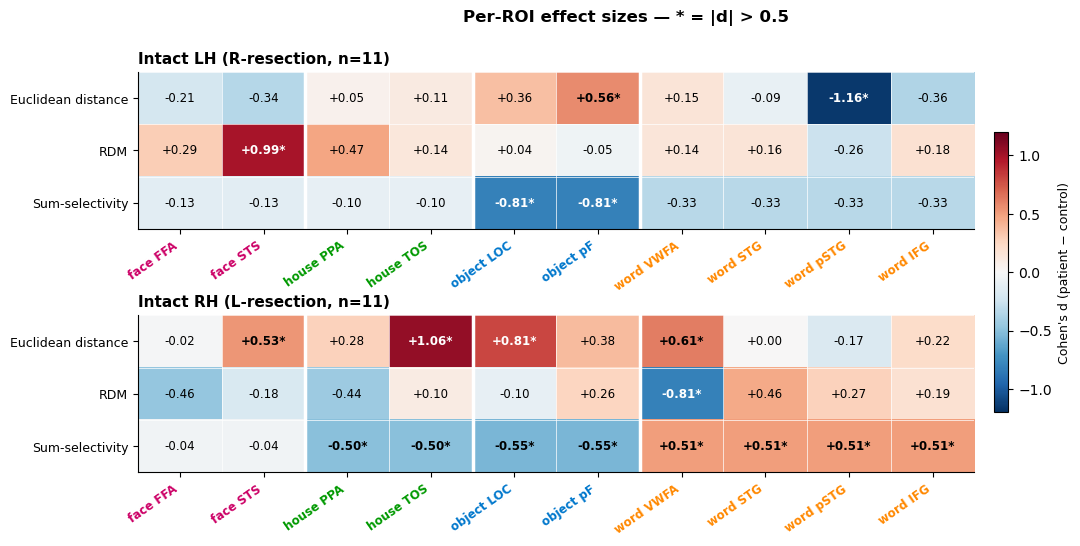

In [61]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ALL_ROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'],
}
MEASURES = ['distance', 'distinct', 'sum_sel']
MEASURE_LABELS = {'distance': 'Euclidean distance',
                  'distinct': 'RDM',
                  'sum_sel':  'Sum-selectivity'}

# Build matrices: rows = measures, cols = ROIs (grouped by cat)
roi_order = [r for cat in ALL_ROIS for r in ALL_ROIS[cat]]
roi_labels = [r.replace('_', ' ').replace('pSTG liu', 'pSTG') for r in roi_order]
cat_of = {r: cat for cat, rs in ALL_ROIS.items() for r in rs}
CAT_COLOR = {'face':'#cc0066', 'house':'#009900', 'object':'#0077cc', 'word':'#ff8800'}

def build_matrix(intact):
    M = np.full((len(MEASURES), len(roi_order)), np.nan)
    for j, roi in enumerate(roi_order):
        for i, meas in enumerate(MEASURES):
            M[i, j] = get_d(intact, roi, meas)
    M[MEASURES.index('distinct'), :] *= -1  # invert so red = more disrupted
    return M

fig, axes = plt.subplots(2, 1, figsize=(13, 5.2),
                         gridspec_kw={'hspace': 0.55})
vmax = 1.2
cmap = plt.cm.RdBu_r
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

for ax, intact, title in [(axes[0], 'l', 'Intact LH (R-resection, n=11)'),
                          (axes[1], 'r', 'Intact RH (L-resection, n=11)')]:
    M = build_matrix(intact)
    im = ax.imshow(M, cmap=cmap, norm=norm, aspect='auto')

    # Cell text + asterisk for |d|>0.5
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if np.isnan(v):
                ax.text(j, i, 'NA', ha='center', va='center', fontsize=8, color='gray')
            else:
                txt = f'{v:+.2f}'
                if abs(v) > 0.5: txt += '*'
                color = 'white' if abs(v) > 0.7 else 'black'
                ax.text(j, i, txt, ha='center', va='center', fontsize=8.5, color=color,
                        fontweight='bold' if abs(v) > 0.5 else 'normal')

    ax.set_xticks(np.arange(len(roi_order)))
    ax.set_xticklabels(roi_labels, rotation=35, ha='right', fontsize=8.5)
    # Color tick labels by parent category
    for tick, roi in zip(ax.get_xticklabels(), roi_order):
        tick.set_color(CAT_COLOR[cat_of[roi]])
        tick.set_fontweight('bold')
    ax.set_yticks(np.arange(len(MEASURES)))
    ax.set_yticklabels([MEASURE_LABELS[m] for m in MEASURES], fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')

    # Vertical separators between categories
    boundaries = np.cumsum([len(ALL_ROIS[c]) for c in ALL_ROIS])[:-1] - 0.5
    for b in boundaries:
        ax.axvline(b, color='white', lw=2.5)

    ax.set_xticks(np.arange(-0.5, len(roi_order), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(MEASURES), 1), minor=True)
    ax.grid(which='minor', color='white', lw=0.5)
    ax.tick_params(which='minor', length=0)

cbar = fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.7, pad=0.02)
cbar.set_label("Cohen's d (patient \u2212 control)", fontsize=9)
fig.suptitle("Per-ROI effect sizes \u2014 * = |d| > 0.5", fontsize=12, fontweight='bold', y=1.0)
plt.savefig(FIG_DIR / 'effect_size_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

R-res patients show disrupted object topography (object_pF distance, sum-sel) with preserved object distinctiveness, but face_STS shows reduced distinctiveness — counterevidence to a clean "topography-only" story for this group. L-res patients show a clear word deficit at VWFA across all three measures.
Notable across both groups: relative peak movement (Euclidean distance) and representational distinctiveness can dissociate — peaks shift without RDM loss (object pF in R-res), and RDM changes without peak shift (face_STS in R-res). The two measures capture different aspects of disruption.

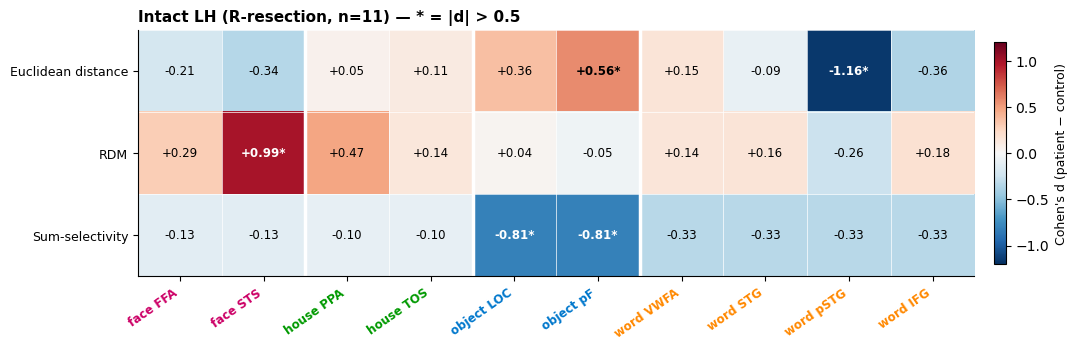

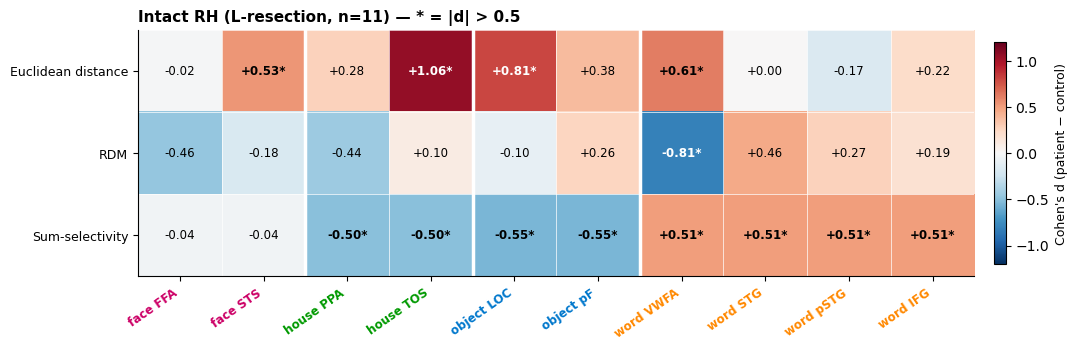

In [62]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

ALL_ROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'],
}
MEASURES = ['distance', 'distinct', 'sum_sel']
MEASURE_LABELS = {'distance': 'Euclidean distance',
                  'distinct': 'RDM',
                  'sum_sel':  'Sum-selectivity'}

# Build matrices: rows = measures, cols = ROIs (grouped by cat)
roi_order = [r for cat in ALL_ROIS for r in ALL_ROIS[cat]]
roi_labels = [r.replace('_', ' ').replace('pSTG liu', 'pSTG') for r in roi_order]
cat_of = {r: cat for cat, rs in ALL_ROIS.items() for r in rs}
CAT_COLOR = {'face':'#cc0066', 'house':'#009900', 'object':'#0077cc', 'word':'#ff8800'}

def build_matrix(intact):
    M = np.full((len(MEASURES), len(roi_order)), np.nan)
    for j, roi in enumerate(roi_order):
        for i, meas in enumerate(MEASURES):
            M[i, j] = get_d(intact, roi, meas)
    M[MEASURES.index('distinct'), :] *= -1  # invert so red = more disrupted
    return M

vmax = 1.2
cmap = plt.cm.RdBu_r
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Group the parameters for each distinct figure
figure_configs = [
    ('l', 'Intact LH (R-resection, n=11)', 'effect_size_heatmap_LH.png'),
    ('r', 'Intact RH (L-resection, n=11)', 'effect_size_heatmap_RH.png')
]

for intact, title, filename in figure_configs:
    # Create a new figure for each iteration. 
    # Height reduced to 3.2 since it's only one panel now.
    fig, ax = plt.subplots(figsize=(13, 3.2)) 
    
    M = build_matrix(intact)
    im = ax.imshow(M, cmap=cmap, norm=norm, aspect='auto')

    # Cell text + asterisk for |d|>0.5
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if np.isnan(v):
                ax.text(j, i, 'NA', ha='center', va='center', fontsize=8, color='gray')
            else:
                txt = f'{v:+.2f}'
                if abs(v) > 0.5: txt += '*'
                color = 'white' if abs(v) > 0.7 else 'black'
                ax.text(j, i, txt, ha='center', va='center', fontsize=8.5, color=color,
                        fontweight='bold' if abs(v) > 0.5 else 'normal')

    ax.set_xticks(np.arange(len(roi_order)))
    ax.set_xticklabels(roi_labels, rotation=35, ha='right', fontsize=8.5)
    
    # Color tick labels by parent category
    for tick, roi in zip(ax.get_xticklabels(), roi_order):
        tick.set_color(CAT_COLOR[cat_of[roi]])
        tick.set_fontweight('bold')
        
    ax.set_yticks(np.arange(len(MEASURES)))
    ax.set_yticklabels([MEASURE_LABELS[m] for m in MEASURES], fontsize=9)
    
    # Added the asterisk note directly to the individual subplot titles
    ax.set_title(f"{title} \u2014 * = |d| > 0.5", fontsize=11, fontweight='bold', loc='left')

    # Vertical separators between categories
    boundaries = np.cumsum([len(ALL_ROIS[c]) for c in ALL_ROIS])[:-1] - 0.5
    for b in boundaries:
        ax.axvline(b, color='white', lw=2.5)

    ax.set_xticks(np.arange(-0.5, len(roi_order), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(MEASURES), 1), minor=True)
    ax.grid(which='minor', color='white', lw=0.5)
    ax.tick_params(which='minor', length=0)

    # Attach the colorbar to the current single axis
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.9, pad=0.02)
    cbar.set_label("Cohen's d (patient \u2212 control)", fontsize=9)
    
    # Save each figure distinctly
    # plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()

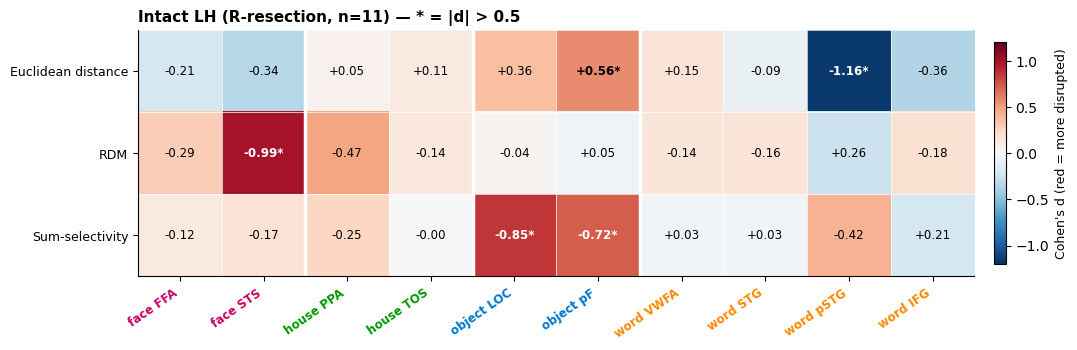

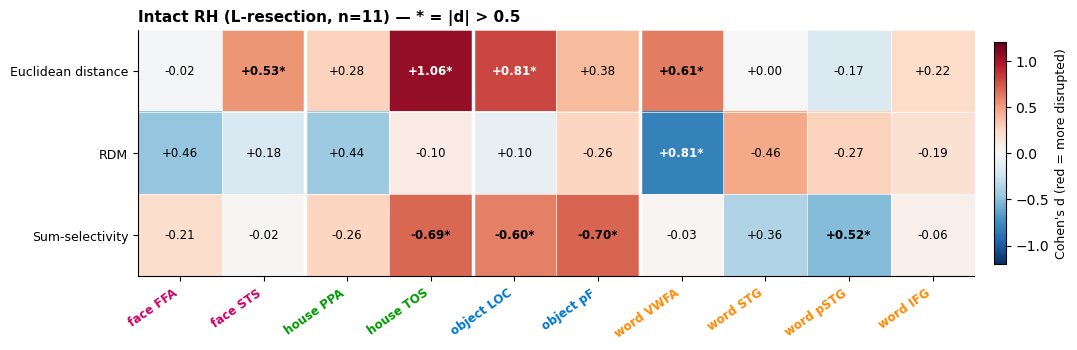

In [65]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

ALL_ROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'],
}
MEASURES = ['distance', 'distinct', 'sum_sel']
MEASURE_LABELS = {'distance': 'Euclidean distance',
                  'distinct': 'RDM',
                  'sum_sel':  'Sum-selectivity'}

roi_order = [r for cat in ALL_ROIS for r in ALL_ROIS[cat]]
roi_labels = [r.replace('_', ' ').replace('pSTG liu', 'pSTG') for r in roi_order]
cat_of = {r: cat for cat, rs in ALL_ROIS.items() for r in rs}
CAT_COLOR = {'face':'#cc0066', 'house':'#009900', 'object':'#0077cc', 'word':'#ff8800'}


def build_matrix(intact):
    """Real signed Cohen's d. No inversion."""
    M = np.full((len(MEASURES), len(roi_order)), np.nan)
    for j, roi in enumerate(roi_order):
        for i, meas in enumerate(MEASURES):
            M[i, j] = get_d_v2(intact, roi, meas)
    return M


def color_value(d, measure):
    """Flip sign for color so 'more disrupted' = red.
    distance: bigger d = farther = more disrupted → no flip
    distinct: smaller d = less distinct = more disrupted → flip
    sum_sel: smaller d = fewer voxels = more disrupted → flip
    """
    if measure in ('distinct', 'sum_sel'):
        return -d
    return d


vmax = 1.2
cmap = plt.cm.RdBu_r
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

figure_configs = [
    ('l', 'Intact LH (R-resection, n=11)', 'effect_size_heatmap_LH.png'),
    ('r', 'Intact RH (L-resection, n=11)', 'effect_size_heatmap_RH.png'),
]

for intact, title, filename in figure_configs:
    fig, ax = plt.subplots(figsize=(13, 3.2))
    M = build_matrix(intact)
    M_color = M.copy()
    for i, meas in enumerate(MEASURES):
        for j in range(M.shape[1]):
            M_color[i, j] = color_value(M[i, j], meas)
    im = ax.imshow(M_color, cmap=cmap, norm=norm, aspect='auto')

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if np.isnan(v):
                ax.text(j, i, 'NA', ha='center', va='center', fontsize=8, color='gray')
            else:
                txt = f'{v:+.2f}'
                if abs(v) > 0.5: txt += '*'
                cv = M_color[i, j]
                color = 'white' if abs(cv) > 0.7 else 'black'
                ax.text(j, i, txt, ha='center', va='center', fontsize=8.5, color=color,
                        fontweight='bold' if abs(v) > 0.5 else 'normal')

    ax.set_xticks(np.arange(len(roi_order)))
    ax.set_xticklabels(roi_labels, rotation=35, ha='right', fontsize=8.5)
    for tick, roi in zip(ax.get_xticklabels(), roi_order):
        tick.set_color(CAT_COLOR[cat_of[roi]])
        tick.set_fontweight('bold')
    ax.set_yticks(np.arange(len(MEASURES)))
    ax.set_yticklabels([MEASURE_LABELS[m] for m in MEASURES], fontsize=9)
    ax.set_title(f"{title} \u2014 * = |d| > 0.5", fontsize=11, fontweight='bold', loc='left')

    boundaries = np.cumsum([len(ALL_ROIS[c]) for c in ALL_ROIS])[:-1] - 0.5
    for b in boundaries:
        ax.axvline(b, color='white', lw=2.5)
    ax.set_xticks(np.arange(-0.5, len(roi_order), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(MEASURES), 1), minor=True)
    ax.grid(which='minor', color='white', lw=0.5)
    ax.tick_params(which='minor', length=0)

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.9, pad=0.02)
    cbar.set_label("Cohen's d (red = more disrupted)", fontsize=9)
    # plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()

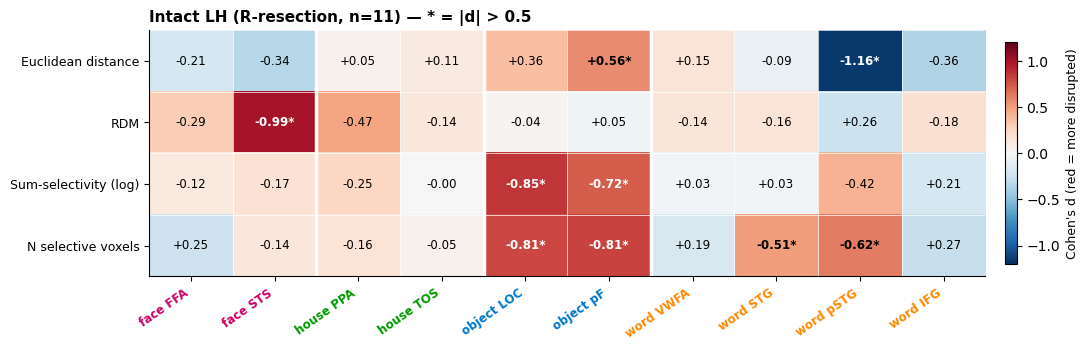

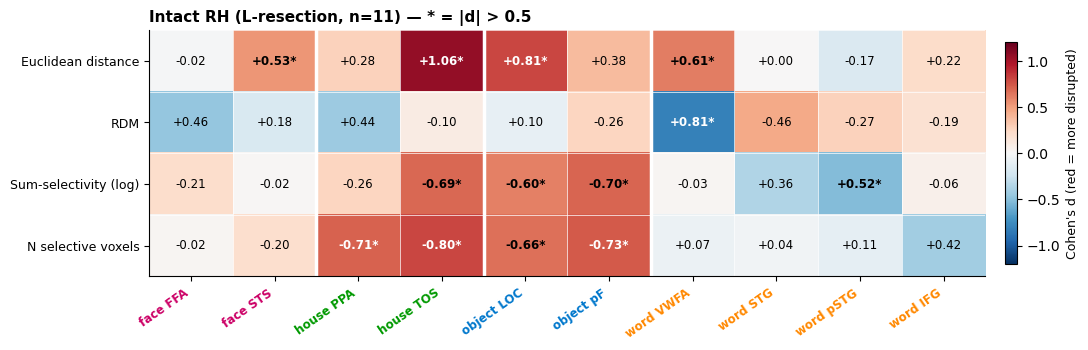

In [66]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

ALL_ROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'],
}

MEASURES = ['distance', 'distinct', 'sum_sel', 'n_voxels']
MEASURE_LABELS = {'distance': 'Euclidean distance',
                  'distinct': 'RDM',
                  'sum_sel':  'Sum-selectivity (log)',
                  'n_voxels': 'N selective voxels'}

def _per_roi_n_voxels(df, subs, roi, hemi):
    sub = df[(df['subject_id'].isin(subs)) & (df['category']==roi) &
             (df['hemi']==hemi)].drop_duplicates(subset=['subject_id'])
    vals = sub['volume'].dropna().values
    return vals[vals > 0]

def get_d_v2(intact, roi, measure):
    if measure == 'sum_sel':
        ct   = _per_roi_volume(ctrl_le, ctrl_subs, roi, intact)
        pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        pt_v = _per_roi_volume(pt_le,   pt_subs,  roi, intact)
    elif measure == 'n_voxels':
        ct   = _per_roi_n_voxels(ctrl_le, ctrl_subs, roi, intact)
        pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        pt_v = _per_roi_n_voxels(pt_le,   pt_subs,  roi, intact)
    elif measure == 'distinct':
        ct  = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==intact)]['liu_distinctiveness'].dropna().values
        pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        pt_v= pt_le[(pt_le['subject_id'].isin(pt_subs)) & (pt_le['category']==roi) &
                    (pt_le['hemi']==intact)]['liu_distinctiveness'].dropna().values
    elif measure == 'distance':
        c = ctrl[(ctrl['category']==roi) & (ctrl['hemi']==intact)][['peak_x_mni','peak_y_mni']].dropna().values
        if len(c)<3: return np.nan
        cen = c.mean(0)
        ct = np.array([np.linalg.norm(p-cen) for p in c])
        pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        p = pt[(pt['subject_id'].isin(pt_subs)) & (pt['category']==roi) &
               (pt['hemi']==intact)][['peak_x_mni','peak_y_mni']].dropna().values
        pt_v = np.array([np.linalg.norm(q-cen) for q in p])
    if len(ct)<3 or len(pt_v)<2: return np.nan
    return (pt_v.mean() - ct.mean()) / np.sqrt((pt_v.var(ddof=1)+ct.var(ddof=1))/2)

def color_value(d, measure):
    if measure in ('distinct', 'sum_sel', 'n_voxels'):
        return -d
    return d

vmax = 1.2
cmap = plt.cm.RdBu_r
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

figure_configs = [
    ('l', 'Intact LH (R-resection, n=11)', 'effect_size_heatmap_LH.png'),
    ('r', 'Intact RH (L-resection, n=11)', 'effect_size_heatmap_RH.png'),
]

for intact, title, filename in figure_configs:
    fig, ax = plt.subplots(figsize=(13, 3.2))
    M = build_matrix(intact)
    M_color = M.copy()
    for i, meas in enumerate(MEASURES):
        for j in range(M.shape[1]):
            M_color[i, j] = color_value(M[i, j], meas)
    im = ax.imshow(M_color, cmap=cmap, norm=norm, aspect='auto')

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if np.isnan(v):
                ax.text(j, i, 'NA', ha='center', va='center', fontsize=8, color='gray')
            else:
                txt = f'{v:+.2f}'
                if abs(v) > 0.5: txt += '*'
                cv = M_color[i, j]
                color = 'white' if abs(cv) > 0.7 else 'black'
                ax.text(j, i, txt, ha='center', va='center', fontsize=8.5, color=color,
                        fontweight='bold' if abs(v) > 0.5 else 'normal')

    ax.set_xticks(np.arange(len(roi_order)))
    ax.set_xticklabels(roi_labels, rotation=35, ha='right', fontsize=8.5)
    for tick, roi in zip(ax.get_xticklabels(), roi_order):
        tick.set_color(CAT_COLOR[cat_of[roi]])
        tick.set_fontweight('bold')
    ax.set_yticks(np.arange(len(MEASURES)))
    ax.set_yticklabels([MEASURE_LABELS[m] for m in MEASURES], fontsize=9)
    ax.set_title(f"{title} \u2014 * = |d| > 0.5", fontsize=11, fontweight='bold', loc='left')

    boundaries = np.cumsum([len(ALL_ROIS[c]) for c in ALL_ROIS])[:-1] - 0.5
    for b in boundaries:
        ax.axvline(b, color='white', lw=2.5)
    ax.set_xticks(np.arange(-0.5, len(roi_order), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(MEASURES), 1), minor=True)
    ax.grid(which='minor', color='white', lw=0.5)
    ax.tick_params(which='minor', length=0)

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.9, pad=0.02)
    cbar.set_label("Cohen's d (red = more disrupted)", fontsize=9)
    # plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()


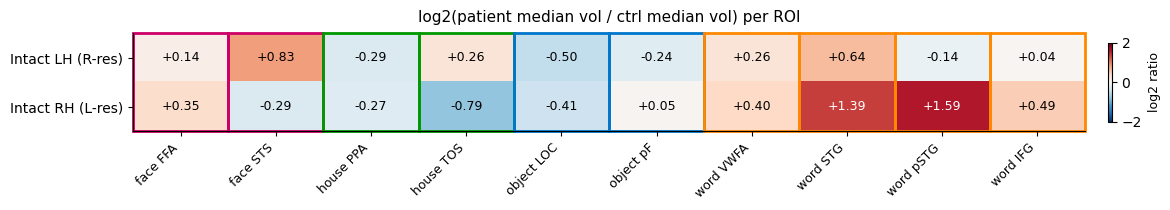

In [70]:
# ── Group log2 ratio: pt median / ctrl median per ROI ──────────────────────
def group_logratio(intact):
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
    out = np.full(len(ALL_ROIS_FLAT), np.nan)
    for j, roi in enumerate(ALL_ROIS_FLAT):
        ct = np.array([vol_per_sub(ctrl_le, s, roi, intact) for s in ctrl_subs])
        pt = np.array([vol_per_sub(pt_le,   s, roi, intact) for s in pt_subs])
        ct = ct[~np.isnan(ct)]; pt = pt[~np.isnan(pt)]
        if len(ct) < 3 or len(pt) < 2: continue
        out[j] = np.log2(np.median(pt) / np.median(ct))
    return out

M = np.vstack([group_logratio('l'), group_logratio('r')])

fig, ax = plt.subplots(figsize=(13, 2.2))
vmax = 2.0
norm_lr = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax.imshow(M, cmap='RdBu_r', norm=norm_lr, aspect='auto')

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        if np.isnan(v):
            ax.text(j, i, 'NA', ha='center', va='center', fontsize=8, color='gray')
        else:
            color = 'white' if abs(v) > 1.3 else 'black'
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=9, color=color)

ax.set_xticks(range(len(ALL_ROIS_FLAT)))
ax.set_xticklabels(roi_labels_flat, rotation=45, ha='right', fontsize=9)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Intact LH (R-res)', 'Intact RH (L-res)'], fontsize=10)
ax.set_title('log2(patient median vol / ctrl median vol) per ROI', fontsize=11, pad=8)

for j, roi in enumerate(ALL_ROIS_FLAT):
    ax.add_patch(plt.Rectangle((j-0.5, -0.5), 1, 2,
                                fill=False, edgecolor=CAT_COLOR[cat_of[roi]],
                                lw=2, clip_on=False))

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('log2 ratio', fontsize=9)
plt.tight_layout()
plt.show()

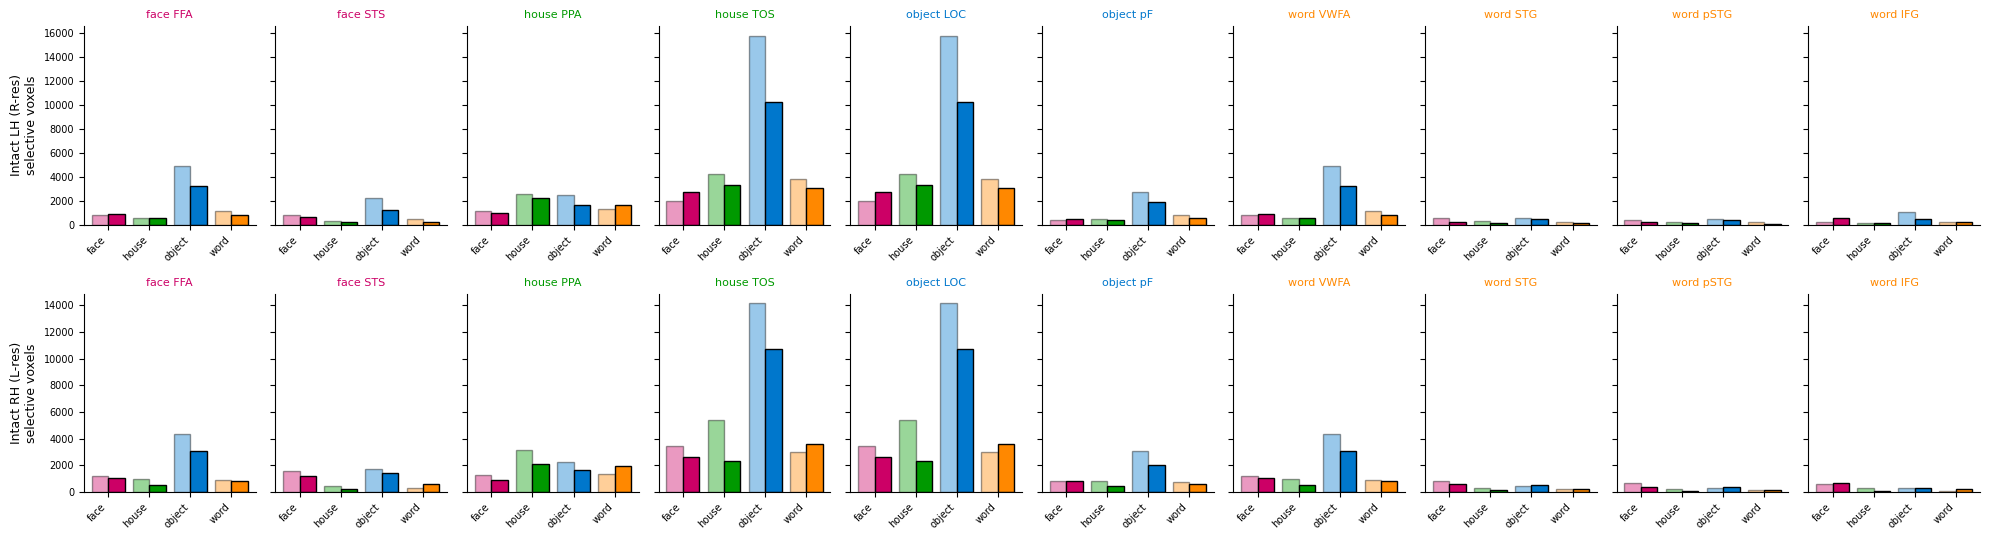

In [75]:
# ── Cross-contrast volume per ROI: topographic competition ──────────────────
cc = pd.read_csv('/user_data/csimmon2/git_repos/sym_pt/cross_contrast_volumes.csv')

# Patient hemi = intact; controls bilateral
def cc_subset(group, intact):
    if group == 'ctrl':
        return cc[cc['subject_id'].isin(ctrl_subs) & (cc['hemi']==intact)]
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
    return cc[cc['subject_id'].isin(pt_subs) & (cc['hemi']==intact)]

CONTRAST_CATS = ['face', 'house', 'object', 'word']
CC_COLOR = {'face':'#cc0066','house':'#009900','object':'#0077cc','word':'#ff8800'}

fig, axes = plt.subplots(2, len(ALL_ROIS_FLAT), figsize=(2.0*len(ALL_ROIS_FLAT), 5.5),
                          sharey='row')
for row, (intact, label) in enumerate([('l','Intact LH (R-res)'),('r','Intact RH (L-res)')]):
    ct = cc_subset('ctrl', intact)
    pt = cc_subset('pt',   intact)
    for col, roi in enumerate(ALL_ROIS_FLAT):
        ax = axes[row, col]
        ct_means = [ct[(ct['roi']==roi)&(ct['contrast_cat']==c)]['volume'].mean() for c in CONTRAST_CATS]
        pt_means = [pt[(pt['roi']==roi)&(pt['contrast_cat']==c)]['volume'].mean() for c in CONTRAST_CATS]
        x = np.arange(len(CONTRAST_CATS))
        ax.bar(x-0.2, ct_means, width=0.4, color=[CC_COLOR[c] for c in CONTRAST_CATS],
               alpha=0.4, edgecolor='black', label='ctrl')
        ax.bar(x+0.2, pt_means, width=0.4, color=[CC_COLOR[c] for c in CONTRAST_CATS],
               edgecolor='black', label='pt')
        ax.set_xticks(x); ax.set_xticklabels(CONTRAST_CATS, rotation=45, ha='right', fontsize=7)
        if col == 0: ax.set_ylabel(f'{label}\nselective voxels', fontsize=9)
        ax.set_title(roi.replace('_',' ').replace('pSTG liu','pSTG'),
                     fontsize=8, color=CAT_COLOR[cat_of[roi]])
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

=== Crawford individual patient counts (log10 volume, p<.05 two-tailed) ===
     group           roi    cat  n_tested  n_lower  pct_lower  n_higher  pct_higher
LH (R-res)      face_FFA   face        11        1          9         0           0
LH (R-res)      face_STS   face        11        2         18         0           0
LH (R-res)     house_PPA  house        11        1          9         0           0
LH (R-res)     house_TOS  house        11        1          9         0           0
LH (R-res)    object_LOC object        11        5         45         0           0
LH (R-res)     object_pF object        11        3         27         0           0
LH (R-res)     word_VWFA   word        10        0          0         0           0
LH (R-res)      word_STG   word         9        0          0         0           0
LH (R-res) word_pSTG_liu   word         9        0          0         0           0
LH (R-res)      word_IFG   word         8        0          0         0           0


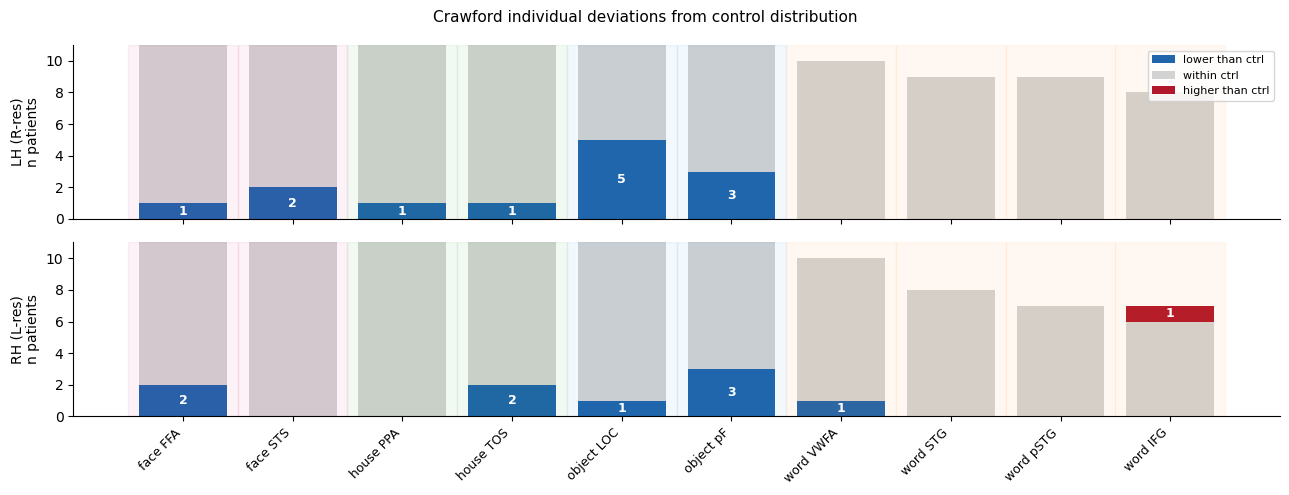

In [73]:
# ── #1: Crawford counts — how many patients deviate per ROI ─────────────────
# Per-patient Crawford modified t-test against control distribution at intact hemi.
# Reports: count of patients with significant deviation per ROI, signed direction.

from scipy.stats import t as tdist

def crawford_t(x, ctrl_vals):
    """Crawford & Howell (1998) modified t-test for single case vs control sample."""
    n = len(ctrl_vals)
    if n < 3 or np.isnan(x): return np.nan, np.nan
    m, sd = np.mean(ctrl_vals), np.std(ctrl_vals, ddof=1)
    if sd == 0: return np.nan, np.nan
    t = (x - m) / (sd * np.sqrt((n + 1) / n))
    p = 2 * (1 - tdist.cdf(abs(t), df=n - 1))
    return t, p

ALPHA = 0.05
rows = []
for intact, label in [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]:
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    for roi in ALL_ROIS_FLAT:
        ct = np.array([vol_per_sub(ctrl_le, s, roi, intact) for s in ctrl_subs])
        ct = ct[~np.isnan(ct)]
        if len(ct) < 3: continue
        ct_log = np.log10(ct)
        n_lower = n_higher = n_tested = 0
        for sub in pt_subs:
            v = vol_per_sub(pt_le, sub, roi, intact)
            if np.isnan(v): continue
            n_tested += 1
            t, p = crawford_t(np.log10(v), ct_log)
            if np.isnan(p): continue
            if p < ALPHA:
                if t < 0: n_lower += 1
                else:     n_higher += 1
        rows.append({
            'group': label, 'roi': roi, 'cat': cat_of[roi],
            'n_tested': n_tested,
            'n_lower':  n_lower,  'pct_lower':  100*n_lower/n_tested if n_tested else np.nan,
            'n_higher': n_higher, 'pct_higher': 100*n_higher/n_tested if n_tested else np.nan,
        })

cf = pd.DataFrame(rows)
print('=== Crawford individual patient counts (log10 volume, p<.05 two-tailed) ===')
print(cf.to_string(index=False, float_format='%.0f'))

# Visualization: stacked bar per ROI showing n_lower / n_higher / n_unchanged
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
for ax, (intact, label) in zip(axes, [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]):
    sub = cf[cf['group'] == label].set_index('roi').reindex(ALL_ROIS_FLAT)
    n_unchanged = sub['n_tested'] - sub['n_lower'] - sub['n_higher']
    x = np.arange(len(ALL_ROIS_FLAT))
    ax.bar(x, sub['n_lower'],   color='#2166ac', label='lower than ctrl')
    ax.bar(x, n_unchanged,      bottom=sub['n_lower'], color='lightgray', label='within ctrl')
    ax.bar(x, sub['n_higher'],  bottom=sub['n_lower']+n_unchanged, color='#b2182b', label='higher than ctrl')
    for j, roi in enumerate(ALL_ROIS_FLAT):
        n_lo = sub.loc[roi, 'n_lower']; n_hi = sub.loc[roi, 'n_higher']; n_t = sub.loc[roi, 'n_tested']
        if n_lo > 0: ax.text(j, n_lo/2, str(int(n_lo)), ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        if n_hi > 0: ax.text(j, n_t - n_hi/2, str(int(n_hi)), ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax.set_ylabel(f'{label}\nn patients', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(roi_labels_flat, rotation=45, ha='right', fontsize=9)
    for j, roi in enumerate(ALL_ROIS_FLAT):
        ax.axvspan(j-0.5, j+0.5, color=CAT_COLOR[cat_of[roi]], alpha=0.05)
    if ax is axes[0]: ax.legend(loc='upper right', fontsize=8)
plt.suptitle('Crawford individual deviations from control distribution', fontsize=11)
plt.tight_layout()
plt.show()

=== Patients outside bootstrapped 95% control range (log10 volume) ===
     group           roi    cat  n_tested  ctrl_median  ctrl_lo  ctrl_hi  n_below  n_above  pct_below
LH (R-res)      face_FFA   face        11         2.89     1.85     3.16        1        3       9.09
LH (R-res)      face_STS   face        11         2.34     0.90     3.48        2        0      18.18
LH (R-res)     house_PPA  house        11         3.38     2.71     3.74        1        0       9.09
LH (R-res)     house_TOS  house        11         3.43     2.43     3.96        1        0       9.09
LH (R-res)    object_LOC object        11         4.19     3.90     4.40        5        1      45.45
LH (R-res)     object_pF object        11         3.43     2.55     3.66        4        0      36.36
LH (R-res)     word_VWFA   word        10         2.95     0.46     3.49        0        1       0.00
LH (R-res)      word_STG   word         9         1.98     0.33     3.32        0        0       0.00
LH (R-res) 

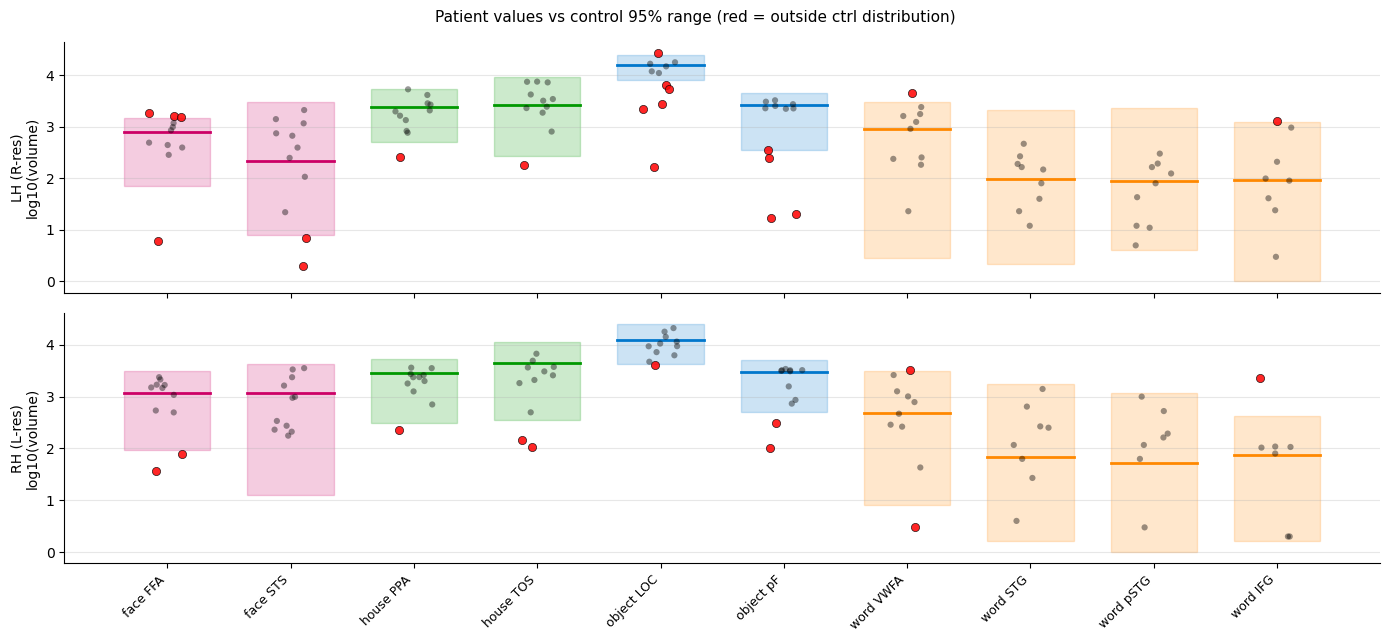

In [76]:
# ── #2 (corrected): Control distribution + individual patient placement ─────
# Build empirical control CI per ROI (95% range = 2.5–97.5 percentile of
# bootstrapped ctrl distribution). Count patients outside that range.

N_BOOT = 10000
rng = np.random.RandomState(42)

def ctrl_ci(ct_vals, n_boot=N_BOOT, ci=95):
    """Bootstrap percentile CI on the control distribution itself."""
    ct_vals = ct_vals[~np.isnan(ct_vals)]
    if len(ct_vals) < 3: return np.nan, np.nan, np.nan
    # The CI on the *distribution* (where individual values lie) is just percentiles of ctrl.
    # Bootstrap stabilizes the percentile estimate.
    lo_q, hi_q = (100 - ci) / 2, 100 - (100 - ci) / 2
    boot_los = np.empty(n_boot); boot_his = np.empty(n_boot)
    for b in range(n_boot):
        s = rng.choice(ct_vals, size=len(ct_vals), replace=True)
        boot_los[b] = np.percentile(s, lo_q)
        boot_his[b] = np.percentile(s, hi_q)
    return np.median(ct_vals), np.median(boot_los), np.median(boot_his)

rows = []
for intact, label in [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]:
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    for roi in ALL_ROIS_FLAT:
        ct = np.array([vol_per_sub(ctrl_le, s, roi, intact) for s in ctrl_subs])
        ct = ct[~np.isnan(ct)]
        if len(ct) < 3: continue
        ct_log = np.log10(ct)
        med, lo, hi = ctrl_ci(ct_log)

        n_below = n_above = n_tested = 0
        pt_logvals = []
        for sub in pt_subs:
            v = vol_per_sub(pt_le, sub, roi, intact)
            if np.isnan(v): continue
            n_tested += 1
            lv = np.log10(v)
            pt_logvals.append(lv)
            if lv < lo:   n_below += 1
            elif lv > hi: n_above += 1

        rows.append({
            'group': label, 'roi': roi, 'cat': cat_of[roi],
            'n_tested': n_tested,
            'ctrl_median': med, 'ctrl_lo': lo, 'ctrl_hi': hi,
            'n_below': n_below, 'n_above': n_above,
            'pct_below': 100*n_below/n_tested if n_tested else np.nan,
        })

ci_df = pd.DataFrame(rows)
print('=== Patients outside bootstrapped 95% control range (log10 volume) ===')
print(ci_df.to_string(index=False, float_format='%.2f'))

# Plot: ctrl 95% range as bar, patient values as dots
fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True)
for ax, (intact, label) in zip(axes, [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]):
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    for j, roi in enumerate(ALL_ROIS_FLAT):
        sub_row = ci_df[(ci_df['group']==label) & (ci_df['roi']==roi)]
        if not len(sub_row): continue
        lo = sub_row['ctrl_lo'].iloc[0]; hi = sub_row['ctrl_hi'].iloc[0]
        med = sub_row['ctrl_median'].iloc[0]
        # ctrl band (95%)
        ax.add_patch(plt.Rectangle((j-0.35, lo), 0.7, hi-lo,
                                    facecolor=CAT_COLOR[cat_of[roi]], alpha=0.2,
                                    edgecolor=CAT_COLOR[cat_of[roi]], lw=1))
        ax.plot([j-0.35, j+0.35], [med, med], color=CAT_COLOR[cat_of[roi]], lw=2)
        # patient dots
        for sub in pt_subs:
            v = vol_per_sub(pt_le, sub, roi, intact)
            if np.isnan(v): continue
            lv = np.log10(v)
            outside = lv < lo or lv > hi
            ax.scatter(j + rng.uniform(-0.15, 0.15), lv,
                       s=35 if outside else 20,
                       color='red' if outside else 'black',
                       alpha=0.85 if outside else 0.4, zorder=3,
                       edgecolor='black' if outside else 'none', linewidth=0.5)
    ax.set_ylabel(f'{label}\nlog10(volume)', fontsize=10)
    ax.set_xticks(range(len(ALL_ROIS_FLAT)))
    ax.set_xticklabels(roi_labels_flat, rotation=45, ha='right', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
plt.suptitle('Patient values vs control 95% range (red = outside ctrl distribution)', fontsize=11)
plt.tight_layout()
plt.show()

In [83]:
# ── Does distance predict RDM? Per-patient, per-ROI ─────────────────────────
from scipy.stats import spearmanr

mni_df = pd.read_csv(MNI_CSV)

def dist_from_ctrl(sub_id, roi, hemi, is_ctrl_pool):
    """Euclidean distance of (sub_id, roi, hemi) peak from the ctrl centroid."""
    c = mni_df[mni_df['subject_id'].isin(ctrl_subs) &
               (mni_df['category']==roi) & (mni_df['hemi']==hemi)] \
        [['peak_x_mni','peak_y_mni']].dropna().values
    if len(c) < 3: return np.nan
    cen = c.mean(0)
    s = mni_df[(mni_df['subject_id']==sub_id) &
               (mni_df['category']==roi) & (mni_df['hemi']==hemi)] \
        [['peak_x_mni','peak_y_mni']].dropna().values
    if not len(s): return np.nan
    return np.linalg.norm(s[0] - cen)

rows = []
for sub in otc_subs:
    intact = pt_intact_hemi(sub)
    if intact is None: continue
    for roi in ALL_ROIS_FLAT:
        d = dist_from_ctrl(sub, roi, intact, False)
        r_row = pt_le[(pt_le['subject_id']==sub) & (pt_le['category']==roi) &
                      (pt_le['hemi']==intact)]
        if not len(r_row): continue
        rdm = r_row['liu_distinctiveness'].iloc[0]
        if np.isnan(d) or np.isnan(rdm): continue
        rows.append({'sub': sub, 'roi': roi, 'cat': cat_of[roi],
                     'intact': intact, 'dist': d, 'rdm': rdm})

pdf = pd.DataFrame(rows)

# Across all (patient × ROI) pairs
rho, p = spearmanr(pdf['dist'], pdf['rdm'])
print(f'All pairs (n={len(pdf)}): Spearman rho = {rho:+.3f}, p = {p:.3f}')

# Per-group
for intact, label in [('l','LH (R-res)'),('r','RH (L-res)')]:
    sub = pdf[pdf['intact']==intact]
    rho, p = spearmanr(sub['dist'], sub['rdm'])
    print(f'{label} (n={len(sub)}): rho = {rho:+.3f}, p = {p:.3f}')

# Per-ROI within each group
print('\nPer-ROI × group:')
for intact, label in [('l','LH'),('r','RH')]:
    for roi in ALL_ROIS_FLAT:
        sub = pdf[(pdf['intact']==intact) & (pdf['roi']==roi)]
        if len(sub) < 5: continue
        rho, p = spearmanr(sub['dist'], sub['rdm'])
        flag = '*' if p < 0.05 else ''
        print(f'  {label} {roi:18s} n={len(sub):2d}  rho={rho:+.3f}  p={p:.3f} {flag}')

All pairs (n=220): Spearman rho = -0.092, p = 0.174
LH (R-res) (n=110): rho = -0.113, p = 0.239
RH (L-res) (n=110): rho = -0.126, p = 0.190

Per-ROI × group:
  LH face_FFA           n=11  rho=-0.018  p=0.958 
  LH face_STS           n=11  rho=+0.009  p=0.979 
  LH house_PPA          n=11  rho=+0.400  p=0.223 
  LH house_TOS          n=11  rho=+0.782  p=0.004 *
  LH object_LOC         n=11  rho=-0.082  p=0.811 
  LH object_pF          n=11  rho=+0.555  p=0.077 
  LH word_VWFA          n=11  rho=-0.164  p=0.631 
  LH word_STG           n=11  rho=+0.109  p=0.750 
  LH word_pSTG_liu      n=11  rho=-0.082  p=0.811 
  LH word_IFG           n=11  rho=+0.245  p=0.467 
  RH face_FFA           n=11  rho=-0.182  p=0.593 
  RH face_STS           n=11  rho=+0.282  p=0.401 
  RH house_PPA          n=11  rho=+0.564  p=0.071 
  RH house_TOS          n=11  rho=-0.255  p=0.450 
  RH object_LOC         n=11  rho=-0.155  p=0.650 
  RH object_pF          n=11  rho=-0.100  p=0.770 
  RH word_VWFA          n

     group           roi    cat  n_tested  ctrl_median  ctrl_lo  ctrl_hi  n_below  n_above
LH (R-res)      face_FFA   face        11         2.89     1.85     3.16        1        3
LH (R-res)      face_STS   face        11         2.34     0.90     3.48        2        0
LH (R-res)     house_PPA  house        11         3.38     2.71     3.74        1        0
LH (R-res)     house_TOS  house        11         3.43     2.43     3.96        1        0
LH (R-res)    object_LOC object        11         4.19     3.90     4.40        5        1
LH (R-res)     object_pF object        11         3.43     2.55     3.66        4        0
LH (R-res)     word_VWFA   word        10         2.95     0.46     3.49        0        1
LH (R-res)      word_STG   word         9         1.98     0.33     3.32        0        0
LH (R-res) word_pSTG_liu   word         9         1.94     0.60     3.37        0        0
LH (R-res)      word_IFG   word         8         1.96     0.00     3.09        0        1

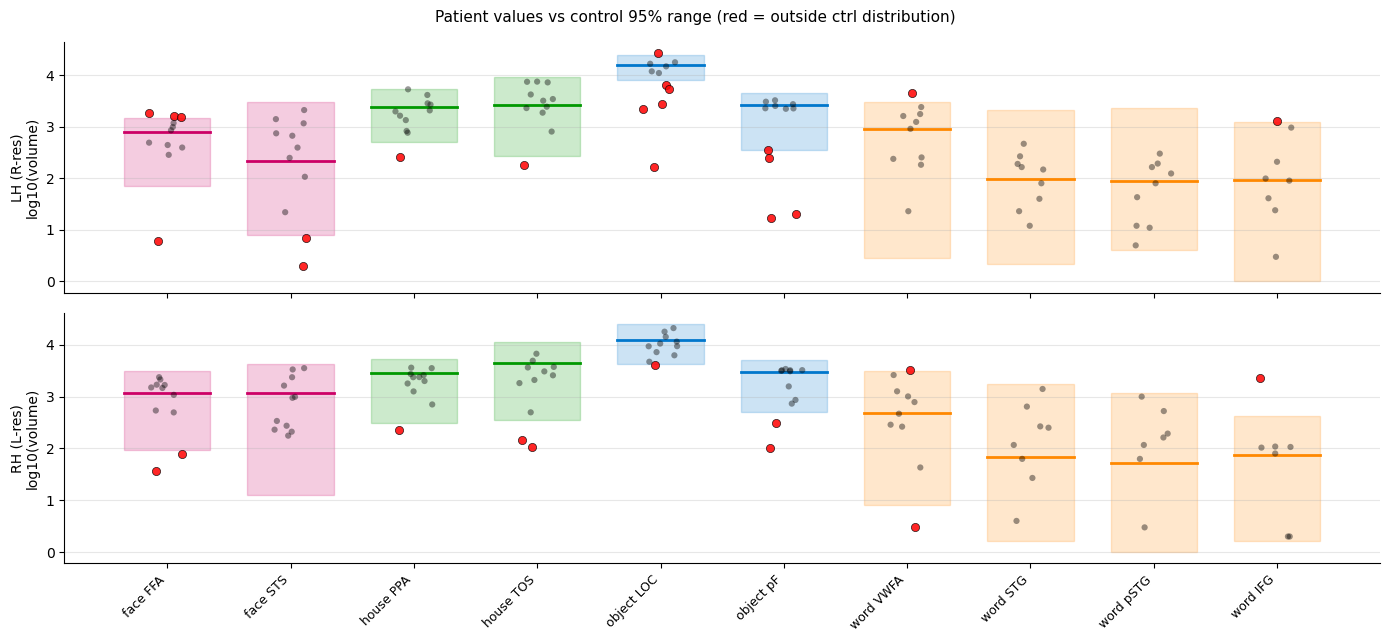

In [105]:
# ── Volume: patients outside bootstrapped 95% control range ─────────────────
N_BOOT = 10000
rng = np.random.RandomState(42)

def vol_per_sub(df, sub, roi, hemi):
    m = df[(df['subject_id']==sub) & (df['category']==roi) & (df['hemi']==hemi)] \
          .drop_duplicates(subset=['subject_id'])
    if not len(m): return np.nan
    v = m['volume'].iloc[0]
    return v if v > 0 else np.nan

def ctrl_ci(ct_vals, n_boot=N_BOOT, ci=95):
    ct_vals = ct_vals[~np.isnan(ct_vals)]
    if len(ct_vals) < 3: return np.nan, np.nan, np.nan
    lo_q, hi_q = (100 - ci) / 2, 100 - (100 - ci) / 2
    boot_los = np.empty(n_boot); boot_his = np.empty(n_boot)
    for b in range(n_boot):
        s = rng.choice(ct_vals, size=len(ct_vals), replace=True)
        boot_los[b] = np.percentile(s, lo_q)
        boot_his[b] = np.percentile(s, hi_q)
    return np.median(ct_vals), np.median(boot_los), np.median(boot_his)

rows = []
for intact, label in [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]:
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    for roi in ALL_ROIS_FLAT:
        ct = np.array([vol_per_sub(ctrl_le, s, roi, intact) for s in ctrl_subs])
        ct = ct[~np.isnan(ct)]
        if len(ct) < 3: continue
        ct_log = np.log10(ct)
        med, lo, hi = ctrl_ci(ct_log)
        n_below = n_above = n_tested = 0
        for sub in pt_subs:
            v = vol_per_sub(pt_le, sub, roi, intact)
            if np.isnan(v): continue
            n_tested += 1
            lv = np.log10(v)
            if lv < lo:   n_below += 1
            elif lv > hi: n_above += 1
        rows.append({
            'group': label, 'roi': roi, 'cat': cat_of[roi],
            'n_tested': n_tested,
            'ctrl_median': med, 'ctrl_lo': lo, 'ctrl_hi': hi,
            'n_below': n_below, 'n_above': n_above,
        })

ci_df = pd.DataFrame(rows)
print(ci_df.to_string(index=False, float_format='%.2f'))

# Plot: ctrl 95% band + patient dots (red if outside)
fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True)
for ax, (intact, label) in zip(axes, [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]):
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    for j, roi in enumerate(ALL_ROIS_FLAT):
        sub_row = ci_df[(ci_df['group']==label) & (ci_df['roi']==roi)]
        if not len(sub_row): continue
        lo = sub_row['ctrl_lo'].iloc[0]; hi = sub_row['ctrl_hi'].iloc[0]
        med = sub_row['ctrl_median'].iloc[0]
        ax.add_patch(plt.Rectangle((j-0.35, lo), 0.7, hi-lo,
                                    facecolor=CAT_COLOR[cat_of[roi]], alpha=0.2,
                                    edgecolor=CAT_COLOR[cat_of[roi]], lw=1))
        ax.plot([j-0.35, j+0.35], [med, med], color=CAT_COLOR[cat_of[roi]], lw=2)
        for sub in pt_subs:
            v = vol_per_sub(pt_le, sub, roi, intact)
            if np.isnan(v): continue
            lv = np.log10(v)
            outside = lv < lo or lv > hi
            ax.scatter(j + rng.uniform(-0.15, 0.15), lv,
                       s=35 if outside else 20,
                       color='red' if outside else 'black',
                       alpha=0.85 if outside else 0.4, zorder=3,
                       edgecolor='black' if outside else 'none', linewidth=0.5)
    ax.set_ylabel(f'{label}\nlog10(volume)', fontsize=10)
    ax.set_xticks(range(len(ALL_ROIS_FLAT)))
    ax.set_xticklabels(roi_labels_flat, rotation=45, ha='right', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
plt.suptitle('Patient values vs control 95% range (red = outside ctrl distribution)', fontsize=11)
plt.tight_layout()
plt.show()

In [110]:
# ── RDM with volume covaried out, matching Cell 34 sample ───────────────────
def get_d_rdm_covaried_v2(intact, roi):
    """Regress out log_vol from RDM; compute d on residuals using same n as Cell 34."""
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
    
    # RDM values (full sample, matches Cell 34)
    ct_rdm = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==intact)] \
             ['liu_distinctiveness'].dropna().values
    pt_rdm = pt_le[(pt_le['subject_id'].isin(pt_subs)) & (pt_le['category']==roi) &
                   (pt_le['hemi']==intact)]['liu_distinctiveness'].dropna().values
    if len(ct_rdm) < 3 or len(pt_rdm) < 2: return np.nan, np.nan
    
    d_raw = (pt_rdm.mean() - ct_rdm.mean()) / \
            np.sqrt((pt_rdm.var(ddof=1) + ct_rdm.var(ddof=1)) / 2)
    
    # For covariate: build paired (rdm, vol) per subject, both groups
    rows = []
    for src_le, subs, group in [(ctrl_le, ctrl_subs, 'ctrl'), (pt_le, pt_subs, 'pt')]:
        for sub in subs:
            r = src_le[(src_le['subject_id']==sub) & (src_le['category']==roi) &
                       (src_le['hemi']==intact)]
            if not len(r): continue
            rdm = r['liu_distinctiveness'].iloc[0]
            v_row = r.drop_duplicates(subset=['subject_id'])
            v = v_row['volume'].iloc[0]
            if np.isnan(rdm) or np.isnan(v) or v <= 0: continue
            rows.append({'group': group, 'rdm': rdm, 'log_vol': np.log10(v)})
    df = pd.DataFrame(rows)
    if (df['group']=='ctrl').sum() < 3 or (df['group']=='pt').sum() < 2:
        return d_raw, np.nan
    
    slope, intercept, _, _, _ = linregress(df['log_vol'], df['rdm'])
    df['resid'] = df['rdm'] - (slope * df['log_vol'] + intercept)
    ct_r = df[df['group']=='ctrl']['resid'].values
    pt_r = df[df['group']=='pt']['resid'].values
    d_resid = (pt_r.mean() - ct_r.mean()) / \
              np.sqrt((pt_r.var(ddof=1) + ct_r.var(ddof=1)) / 2)
    return d_raw, d_resid

print(f'{"Group":12s} {"ROI":18s} {"d_raw":>8s} {"d_covaried":>12s}')
print('-'*55)
for intact, label in [('l','LH (R-res)'), ('r','RH (L-res)')]:
    for roi in ALL_ROIS_FLAT:
        d_raw, d_resid = get_d_rdm_covaried_v2(intact, roi)
        if np.isnan(d_raw): continue
        print(f'{label:12s} {roi:18s} {d_raw:+8.2f} {d_resid:+12.2f}')

Group        ROI                   d_raw   d_covaried
-------------------------------------------------------
LH (R-res)   face_FFA              -0.29        -0.34
LH (R-res)   face_STS              -0.99        -1.06
LH (R-res)   house_PPA             -0.47        -0.48
LH (R-res)   house_TOS             -0.14        -0.14


LH (R-res)   object_LOC            -0.04        +0.31
LH (R-res)   object_pF             +0.05        +0.48
LH (R-res)   word_VWFA             -0.14        -0.09
LH (R-res)   word_STG              -0.16        +0.31
LH (R-res)   word_pSTG_liu         +0.26        +0.55
LH (R-res)   word_IFG              -0.18        -0.10
RH (L-res)   face_FFA              +0.46        +0.45
RH (L-res)   face_STS              +0.18        +0.20
RH (L-res)   house_PPA             +0.44        +0.42
RH (L-res)   house_TOS             -0.10        -0.21
RH (L-res)   object_LOC            +0.10        -0.06
RH (L-res)   object_pF             -0.26        -0.05
RH (L-res)   word_VWFA             +0.81        +0.95
RH (L-res)   word_STG              -0.46        -0.18
RH (L-res)   word_pSTG_liu         -0.27        +0.08
RH (L-res)   word_IFG              -0.19        -0.37


n=38: Spearman ρ=+0.328, p=0.044 | Pearson r=+0.211, p=0.203


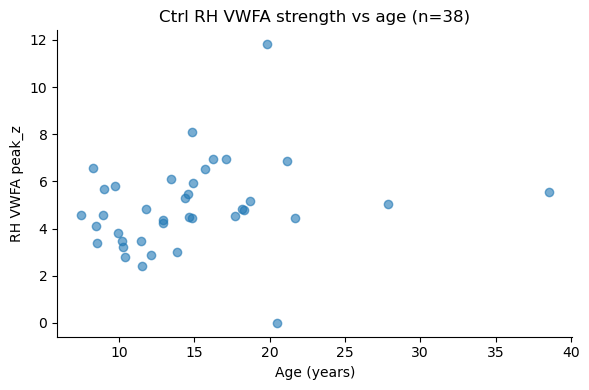

In [111]:
# ── RH VWFA peak_z vs control age ──────────────────────────────────────────
from scipy.stats import spearmanr, pearsonr

age_map = sub_info.drop_duplicates('sub').set_index('sub')['age']

rh_vwfa = ctrl_le[(ctrl_le['category']=='word_VWFA') & (ctrl_le['hemi']=='r')] \
          .drop_duplicates('subject_id').set_index('subject_id')['peak_z']
common = [s for s in rh_vwfa.index if s in age_map.index]
ages = age_map.loc[common].values
zs = rh_vwfa.loc[common].values
mask = ~(np.isnan(ages) | np.isnan(zs))
ages, zs = ages[mask], zs[mask]

rho, p_s = spearmanr(ages, zs)
r, p_p = pearsonr(ages, zs)
print(f'n={len(ages)}: Spearman ρ={rho:+.3f}, p={p_s:.3f} | Pearson r={r:+.3f}, p={p_p:.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(ages, zs, alpha=0.6)
ax.set_xlabel('Age (years)'); ax.set_ylabel('RH VWFA peak_z')
ax.set_title(f'Ctrl RH VWFA strength vs age (n={len(ages)})')
plt.tight_layout(); plt.show()